# Neural Networks

In this notebook I'll be going over what neural networks are, different concepts related to them, what deep learning is compared to artificial intelligence and machine learning, in highly in-depth detail.
It is worth noting that this notebook will serve as a precursor to MANY of the other notebooks and sections within this repo.

## What Are Neural Networks?

Imagine you're teaching a friend to recognize cats in photos. You might say:
- "Look for pointy ears"
- "Check for whiskers" 
- "See if it has four legs"

But what if the photo is blurry? What if the cat is sleeping and you can't see its ears? Traditional programming would require you to write thousands of rules for every possible scenario, like a million if statements. Neural networks take a completely different approach: they (slowly) **learn** by looking at thousands of examples and discovering patterns themselves, then applying that knowledge to new test samples they may see, and then make guesses (or in general, outputs) for that test sample. The format of that test sample depends on what the task being performed is.

### Inspiration from the human brain

Your brain is made up of about 86 billion neurons, each connected to thousands of others. While biological neurons are far more complex than artificial ones, the basic idea behind them inspired neural networks.

Here’s how a single biological neuron works:

1. **Receives signals**: A neuron receives tiny electrical impulses from other neurons through connections called *synapses*. These signals represent information, like seeing the color red, hearing your name, or feeling pressure on your skin.

2. **Weighs and accumulates input**: The neuron adds up all the incoming signals. Some strengthen the total (excitatory), others weaken it (inhibitory), similar to how artificial neurons use weights. For example, if you see a red light (signal 1), hear screeching tires (signal 2), and feel a jolt (signal 3), your brain weighs these signals together as part of a “danger” pattern.

3. **Fires if a threshold is reached**: If the combined input crosses a certain threshold, the neuron “fires”,sending its own signal down the line to other neurons. This can trigger a chain reaction, like flinching, raising your heart rate, or turning your head. If the threshold isn’t met, the signal dies out.
This simple process, repeated billions of times across your brain, enables you to recognize faces, understand language, and make complex decisions.

### Artificial Neural Networks

We can simulate the biological process of neurons using mathematics:

- **Instead of electrical signals** → We use **numbers**: These numbers represent the intensity or importance of an input (e.g., how dark a pixel is, or how common a word is).
  
- **Instead of synapses** → We use **weights**: Each connection between neurons has a weight, a number that determines how much influence that input should have. A **high positive weight** strengthens the signal, a **low or negative weight** weakens or even flips it. During training, these weights are adjusted to help the network make better predictions, giving different inputs different levels of influence/importance (based on how useful they are for the task). Inputs which are more important for completing certain tasks (e.g. predicting house prices, or predicting youtube views) tend to therefore have higher weights.

- **Instead of firing** → We use **activation functions**: These are mathematical functions that decide whether a neuron “activates” (i.e., passes information forward). If the weighted sum of inputs is strong enough, the activation function outputs a signal (like a number close to 1). If it's too weak, it may output 0 or something close to it, effectively shutting off the neuron, meaning it passes on 0 information onto any of the neurons (in the next layer) that it is connected to.

So just like biological neurons fire when signals are strong enough, artificial neurons "activate" based on the strength of their combined inputs (which is just the artificial neuron deciding whether to pass on information or not).

### A Concrete Example: Predicting House Prices

Let's start with something concrete. Imagine you want to predict house prices based on:
- Square footage
- Number of bedrooms
- Age of house

A neural network would:
1. **Take these numbers as input** (e.g., 2000 sq ft, 3 bedrooms, 10 years old)
2. **Process them mathematically** (multiply by weights, add biases, apply activation functions)
3. **Output a prediction** (e.g., $450,000)

### What You'll Master in This Journey

By the end of this notebook, you'll understand and implement every component of neural networks:

**Foundation Concepts:**
- **Linear Layers**: The basic building blocks that transform data
- **Weights**: Numbers that control how much each input matters  
- **Biases**: Adjustment values that help the network fit data better
- **Activation Functions**: Mathematical functions that add intelligence

**The Learning Process:**
- **Forward Propagation**: How data flows through the network to make predictions
- **Loss Functions**: How we measure prediction accuracy
- **Gradient Descent**: How the network learns from mistakes
- **Backpropagation**: How the network figures out what to adjust

**Practical Implementation:**
- **Complete Neural Network**: Built from scratch in Python
- **Real Examples**: Working with actual data and problems
- **Debugging Techniques**: How to make networks work well

> ⚠️ **Prerequisites**: Basic understanding of linear algebra, calculus, and Python programming will be helpful but not strictly required. We'll explain concepts from first principles.


## AI vs ML vs Deep Learning

Before building neural networks, let's understand exactly what they are and how they fit into the bigger picture of artificial intelligence.

### Understanding AI, Machine Learning, and Deep Learning

Imagine you're building a system that can drive a car. There are three fundamentally different ways you could approach the problem:

---

#### 1. **Artificial Intelligence (AI)** - Manually coded rules

**Approach**: Hard-code all the logic by hand.

- "If the light is red, stop."
- "If a car is within 5 meters and slowing down, apply brakes."
- "If the speed limit is 25 mph, don’t exceed it."

You're programming the system to **imitate human decision-making**, but only through explicit instructions.

Example:
```python
if temperature > 100:
    alert("Too hot!")
if light_is_red and car_speed > 0:
    apply_brakes()
```

**Limitation**: You’d need to anticipate and code **every possible scenario** — rain, pedestrians, construction zones, missing road signs, etc. This quickly becomes unmanageable.

---

#### 2. **Machine Learning (ML)** - Learn from data

**Approach**: Instead of writing rules, you let the system **learn patterns** from driving data.

- Give it thousands of examples of good vs. bad driving behavior.
- The system identifies correlations: e.g., “If cars ahead slow down, I probably should too.”

Here, you don’t tell it *what* to do, you give it data, and it finds useful rules on its own.

**Advantage**: Learns to generalize beyond what you manually coded. Can adapt to edge cases you didn’t explicitly program.

---

#### 3. **Deep Learning (DL)** — Learn complex behavior directly from raw input

**Approach**: Use deep neural networks to process raw data like camera feeds, lidar, or GPS.

- A neural network processes the camera input and learns to detect:
  - “This is a stop sign”
  - “That’s a pedestrian”
  - “These are lane markings”
- Then, it uses that understanding to decide how to drive.

**What makes it special**:
- No hand-crafted features — it learns **everything end-to-end**
- It can handle **complex, high-dimensional data** like images, audio, or text
- The network discovers **hierarchies of features** on its own (e.g., edges → shapes → objects → driving cues)

---

### Summary

| Approach        | Input               | Learns from data? | Needs rules?       | Handles raw data?         |
|----------------|---------------------|-------------------|--------------------|---------------------------|
| AI             | Rules + Logic        | ❌ No             | ✅ Yes             | ❌ No                     |
| ML             | Labeled Examples     | ✅ Yes            | ❌ Not directly     | ❌ No (needs pre-processed features) |
| DL             | Raw sensor input     | ✅ Yes            | ❌ No              | ✅ Yes                    |

> **What are "features"?**  
> In machine learning, *features* are simplified representations of the input data. For example, instead of feeding in an entire image, you might first extract things like the number of edges, object positions, or average color. These are features. Traditional ML models rely on **manually designed** features. Deep learning learns them *automatically* from raw data like pixels or waveforms.
---

### Real-World Definitions

Now let's formalize these concepts:

#### Artificial Intelligence (AI) 
**Simple Definition**: Making machines do things that would normally require human intelligence

**Examples in Your Daily Life**:
- Netflix recommending movies you'll like
- Google Maps finding the fastest route
- Spam filters catching unwanted emails
- Voice assistants understanding what you say

**Think of it as**: The broadest category - any computer system that acts "intelligently"

#### Machine Learning (ML) 
**Simple Definition**: Teaching computers to learn patterns from data instead of programming explicit rules

**The Key Insight**: Instead of writing "if-then" rules, show the computer lots of examples and let it figure out the patterns.

**Real Example**: Email spam detection
- **Traditional Programming**: Write rules like "if email contains 'FREE MONEY', mark as spam"
- **Machine Learning**: Show 100,000 examples of spam vs legitimate emails, let the system discover what makes emails spammy

**Examples You Use**:
- Amazon suggesting products you might buy
- Banks detecting fraudulent credit card transactions
- Music apps creating personalized playlists

#### Deep Learning (DL)
**Simple Definition**: Machine learning using artificial neural networks that mimic how the brain processes information

**The Key Insight**: Create artificial "neurons" that work together in layers, like neurons in your brain.

**Why "Deep"?**: Because these networks have many layers (often 10-1000+ layers), allowing them to learn very complex patterns.

**Examples You Use Daily**:
- Photos automatically recognizing and tagging your friends
- Google Translate converting between languages
- Siri/Alexa understanding your voice
- Tesla's self-driving capabilities

### The Relationship: Nested Circles

Think of these as nested circles, where each inner circle is a subset of the outer one:

```
🤖 ARTIFICIAL INTELLIGENCE (Broadest Category)
├── Rule-based systems (traditional programming)
├── Search algorithms (like GPS route finding)
├── Expert systems (like medical diagnosis tools)
└── 📊 MACHINE LEARNING (Learning from data)
    ├── Linear regression (predicting house prices)
    ├── Decision trees (yes/no decision making)
    ├── Clustering (grouping similar customers)
    └── 🧠 DEEP LEARNING (Neural networks)
        ├── Feedforward networks (basic neural nets)
        ├── Convolutional networks (for images)
        ├── Recurrent networks (for sequences)
        └── Transformers (for language, like ChatGPT)
```

### Another Concrete Example: Recognizing Cats in Photos

Let's see how each approach would tackle the same problem:

#### Traditional AI Approach:
```
if (has_pointed_ears AND has_whiskers AND has_four_legs):
    return "cat"
elif (round_shape AND orange_color):
    return "maybe cat"
...
```
**Problem**: Would need thousands of rules and still fail on unusual cats!

#### Traditional ML Approach:
- Manually extract features: "ear pointiness," "whisker length," "fur texture"
- Feed these numbers to an algorithm that learns patterns like: "If ear pointiness > 0.7 AND whisker length > 0.5, then probably cat"

#### Deep Learning Approach:
- Feed raw pixels directly to a neural network
- The network automatically learns to detect edges, then shapes, then cat features, then whole cats
- No manual feature engineering required!

### Why This Progression Matters

Each approach builds on the previous:

1. **Traditional AI** taught us that machines can solve logical problems
2. **Machine Learning** taught us that machines can learn from data
3. **Deep Learning** taught us that machines can learn incredibly complex patterns from raw data

### When to Use What?

| Problem Type | Best Approach | Why |
|-------------|---------------|-----|
| **Simple rules** | Traditional AI | Clear logic, interpretable |
| **Pattern recognition in structured data** | Traditional ML | Good performance, explainable |
| **Complex patterns in unstructured data** | Deep Learning | Handles complexity humans can't program |

**Examples**:
- Calculator app → Traditional AI
- Predicting tomorrow's stock price → Traditional ML  
- Recognizing speech or images → Deep Learning

### Where We're Going

In this notebook, we're focusing on **Deep Learning**, specifically neural networks. These are the foundation for:
- Image recognition (Camera's face recognition)
- Language understanding (ChatGPT, Google Translate)
- Game playing (AlphaGo, OpenAI Five)
- Self-driving cars
- Drug discovery
- And much more!

Neural networks are like the Swiss Army knife of AI; they're incredibly versatile tools that can learn almost any pattern if given enough data and computation.


## Linear Layers and the Foundation of Neural Networks

Before we dive into the complexity of neural networks, let's start with the absolute fundamentals. Think of this as learning to read before you write poetry, we need to understand each component thoroughly.

Neural networks are made up of layers. Each layer considers neurons (nodes). There are multiple types of layers, and linear layers are one of the most fundamental types of layers.

### What Exactly is a Linear Layer?

A **linear layer** (also called a "fully connected layer" or "**dense layer**") is the most basic building block of neural networks. But what does it actually do?

**In the simplest terms**: It takes some numbers as input and produces other numbers as output using a mathematical transformation.

**The Core Concept**: Every linear layer performs exactly this operation:
```
Output (vector of size m) = (Input (vector of size n) × Weight (2D vector of size n x m) ) + Bias (vector of size m)
```
(This means every layer takes a vector of inputs and produces a vector of outputs.)

Let's unpack this piece by piece.

### Understanding the Components: A Complete Breakdown

#### Component 1: Inputs (The Data)

**What are inputs?**: These are simply numbers that represent features of whatever you're trying to analyze.

**Real Examples**:
- **Image recognition**: Each input might be the brightness of a pixel (0-255)
- **House price prediction**: Inputs might be [square_feet, bedrooms, bathrooms, age]
- **Movie recommendation**: Inputs might be [action_rating, comedy_rating, drama_rating]

#### Component 2: Weights (The Learned Importance)

**What are weights?**: Numbers that the network learns during training to determine how important each input is.

**Critical Insight**: These are **NOT** fixed! They start random and change during learning!

**How to interpret weights**:
- **Positive weight** (e.g., +2.5): This input contributes positively to the neuron’s output, the higher the input, the higher the output for that neuron.
- **Negative weight** (e.g., -1.8): This input contributes negatively, the higher the input, the lower the output for that neuron.
- **Near-zero weight (e.g., 0.1)**: This input has very little influence on the overall output. Even if a large input gets multiplied by a small weight, its contribution becomes negligible. The network is effectively ignoring this input when producing the output vector.

To make this idea of near-zero weights rendering certain inputs very non-influential to the contribution of the output clear, I will go through an example that clearly illustrates this.

Let’s say we have:

**Input vector**:  
x = [10, 5, 1]

**Weight matrix** (3 inputs → 2 outputs):
W = 
[[ 0.9,   0.01  ],
 [ 0.4,  -0.02  ],
 [ 0.7,   0.005 ]]

**Bias vector** (we haven't gone over this yet, so making it 0 for simplicitys sake):  
b = [0, 0]

---

**Step 1: Matrix multiplication** (@ means matrix multiplication)
x @ W = [10, 5, 1] @ W  
       = [ (10×0.9 + 5×0.4 + 1×0.7), (10×0.01 + 5×(-0.02) + 1×0.005) ]  
       = [ 9 + 2 + 0.7, 0.1 - 0.1 + 0.005 ]  
       = [ 11.7, 0.005 ]

**Step 2: Add bias**

Output = [11.7, 0.005]

---

### Interpretation

- First output neuron has large weights → output = 11.7
- Second output neuron has tiny weights → output barely changes = 0.005

**Conclusion**: Small weights in the weight matrix “mute” the specific input values that they effect, no matter how big those specific input values are.

#### Component 3: Bias (The Crucial Shift)

**What is bias?**: A single number added to the final calculation that shifts the entire function up or down.

**Why is bias absolutely essential?**: Without bias, our function can only pass through the origin (0,0). With bias, we can position our function anywhere we need it.

Let's see why this matters with a concrete example.

### Step-by-Step Example: Predicting Coffee Preference

Imagine we want to predict how much someone will like a coffee (0-10 scale) based on:
- **Input 1**: Sweetness level (0-10)
- **Input 2**: Strength level (0-10)

#### Without Bias: The Limitation

```
Like_Score = (Sweetness × Weight1) + (Strength × Weight2)

Let's say: Weight1 = 0.7, Weight2 = 0.3

Examples:
- No sweetness, no strength: (0 × 0.7) + (0 × 0.3) = 0
- Medium sweet, medium strong: (5 × 0.7) + (5 × 0.3) = 5.0
- Very sweet, very strong: (10 × 0.7) + (10 × 0.3) = 10.0
```

**Problem**: The prediction for having no sweetness and no strength is **ALWAYS** 0, since both both inputs are 0. But what if someone naturally likes plain, non-sweetened coffee a little bit?

#### With Bias: The Solution

```
Like_Score = (Sweetness × Weight1) + (Strength × Weight2) + Bias

Same weights: Weight1 = 0.7, Weight2 = 0.3
Add bias: Bias = 2.0

Examples:
- No sweetness, no strength: (0 × 0.7) + (0 × 0.3) + 2.0 = 2.0
- Medium sweet, medium strong: (5 × 0.7) + (5 × 0.3) + 2.0 = 7.0  
- Very sweet, very strong: (10 × 0.7) + (10 × 0.3) + 2.0 = 12.0
```
**Now our model can handle the baseline preference!** The bias of 2.0 means "even plain coffee gets a score of 2."

However, if you were paying close attention, you might've seen one of the limitations here.

### Limitation: Inputs of Zero Always Yield the Bias

When both inputs are zero (Sweetness = 0, Strength = 0), the output is **always equal to the bias**. That means the model **cannot distinguish between different people** who all happen to input zeros. It will return the same score no matter what.  

So, if one person *LOVES* plain, unsweetened coffee and another *HATES* it, the model will **always predict the same score** for both, meaning the model predicts completely wrong for at least 1 of the those 2 people. That’s a major issue in real-world modeling where context or personal preferences matter.

#### How to Handle This

To fix this, models usually:
- **Add more features** (like user preferences, demographics, past ratings, features that are just more specific and low-level detailed)
- **Use deeper neural networks** with non-linear activation functions (these are covered later), so it can learn more complex relationships beyond just linear sums (the `Output = (Input x Weight) + Bias` stuff we talked about earlier). These are covered later.
- **Use embeddings** for users or items to capture nuanced differences even when raw inputs look similar. You can read about embeddings in `vector_embeddings` in the `vector_search` section of this repo.

This is a great example of how **bias helps**, but **feature design and network architecture** still matter when you want your model to be expressive and accurate.

You also may have noticed, that the last example with bias addition (very sweet very strong) yields a score outside the range we originally mentioned at the start (0-10).
To overcome this issue, we can apply mathematical functions that bound the output into the acceptable range (so it gets turned into a number between 1 and 10 specifically). These are covered later.

### Mathematical Notation

When you see this in textbooks:
$$y = Wx + b$$

It just means:
- $y$ = output (what we're predicting)
- $W$ = weights (the importance multipliers) 
- $x$ = inputs (our data)
- $b$ = bias (the shift amount)
- All of these elements are referring to vectors!

### From One Input to Multiple Inputs

Real-world problems usually have multiple inputs. Here's how it works:

#### Example: Predicting House Prices

```
Inputs:
x₁ = 2000 (square feet)
x₂ = 3 (bedrooms)  
x₃ = 2 (bathrooms)

Weights (learned during training):
w₁ = 150 (dollars per square foot)
w₂ = 10000 (dollars per bedroom)
w₃ = 5000 (dollars per bathroom)

Bias:
b = 50000 (base house value)

Calculation:
Price = (2000 × 150) + (3 × 10000) + (2 × 5000) + 50000
Price = 300000 + 30000 + 10000 + 50000 = $390,000
```

### But How Does the Network Learn These Numbers?

**This is the magic of machine learning**: The network figures out and determines the values for weights and bias automatically!

**The Learning Process**:
1. **Start**: Random weights and bias (network knows nothing initially, so it just chooses random weights and bias for everything)
2. **Predict**: Use current weights to make predictions (they might be extremely wrong!)
3. **Compare**: See how wrong the predictions are compared to actual known values, by calculating errors
4. **Adjust**: Change weights and bias to reduce errors
5. **Repeat**: Do this thousands of times, and eventually, over time, the errors will get reduced to very small values

**Simple Learning Example**:
```
Goal: Predict house price for a 1000 sq ft house
True price: $200,000

Attempt 1:
Current weight = 50, bias = 0
Prediction = 1000 × 50 + 0 = $50,000
Error = $150,000 too low!

Learning: "I need to increase the weight and add some bias"

Attempt 2:  
New weight = 150, bias = 50000
Prediction = 1000 × 150 + 50000 = $200,000
Error = Perfect! ✓
```
This is an extremely simple. In actuality, a lot more steps, attempts, weights and nodes are involved!

### From Linear Layer to Artificial Neuron

A linear layer alone is just basic math. To create intelligence, we need one more crucial component: **non-linearity**.

**The Complete Artificial Neuron** has two steps:
```
Step 1: Linear transformation (what we just learned)
z = (Inputs × Weights) + Bias

Step 2: Activation function (adds intelligence, also known as non linearity).
output = activation_function(z)
```

**Why do we need Step 2?** Because real neurons in your brain don't just pass signals through, they decide whether to "fire" based on the strength of the input. We mimic this with activation functions. Some neuron nodes should only pass values through if the linear combination exceeds a certain threshold.
Whether or not it exceeds certain thresholds or not is determined by the activation function of our choice that we've chosen!

### Visual Breakdown of a Single Neuron

```
INPUTS → WEIGHTS → LINEAR COMBINATION → ACTIVATION → OUTPUT

x₁=2 ──→ w₁=0.5 ──┐
                  ├─→ z = 0.5×2 + 0.3×3 + 1 = 3.4 ──→ f(3.4) ──→ final_output
x₂=3 ──→ w₂=0.3 ──┘
                  
bias=1 ────────────┘
```

### Multiple Neurons Make a Layer

When we have multiple neurons processing the same inputs:

```
Input: [x₁, x₂] = [2, 3]

Neuron 1: (2×0.5) + (3×0.3) + 1.0 = 2.9 → activation → output₁
Neuron 2: (2×-0.2) + (3×0.8) + 0.5 = 2.5 → activation → output₂  
Neuron 3: (2×0.7) + (3×-0.1) + 0.0 = 1.1 → activation → output₃

Layer Output: [output₁, output₂, output₃]
```

Each neuron has its own weights and bias, but they all process the same inputs.

### Multiple Layers Make a Network

```
INPUT DATA
    ↓
LAYER 1 (transforms input features)
    ↓  
LAYER 2 (combines Layer 1 features)
    ↓
LAYER 3 (makes final decision)
    ↓
FINAL PREDICTION
```

The output of each layer becomes the input to the next layer!

Here's a visualisation of this process (and yes this also means that every layers full-layer output is fed into EACH of the nodes in the next layer)

![Neural Network Graph](../media/nns1.png)

And to solidfy the complete pipeline that happens at every node in the network:

![Individual Neuron Steps](../media/nns2.png)

This diagram shows how each node receives inputs from EVERY SINGLE NODE in the previous layer, performs a linear combination with its own weights and bias, applies an activation function, and produces a single number. That number becomes one element of the next layer’s input vector.

### Why This Simple Building Block is So Powerful

1. **Universal Approximation**: Stack enough of these layers and you can approximate any function
2. **Automatic Feature Discovery**: The network learns what features matter
3. **Hierarchical Learning**: Early layers learn simple patterns, later layers learn complex combinations
4. **Scalability**: Works with millions of inputs and parameters (you have heard of how different models have milliosn or billions of parameters. This is what they mean by that)

It's worth noting that parameters includes things such as weights, biases, and in some cases, things like scaling factors, embeddings, etc., depending on the architecture

Additionally, layers in a neural network that are not the input or output layer, are known as hidden layers.

### Common Beginner Confusion Cleared Up

**Q**: "How do we know what weights to use?"
**A**: We don't! The network learns them automatically through training.

**Q**: "How do we choose the bias?"
**A**: We don't! The bias is also learned automatically.

**Q**: "What if we choose the wrong architecture?"
**A**: That's where experience and experimentation come in, but the basic building blocks remain the same.

### Summary

You now understand:
- **Linear layers**: Transform inputs using learned weights and bias
- **Weights**: Numbers that determine input importance (learned automatically)
- **Bias**: Critical shift that positions the function correctly (learned automatically)
- **Neurons**: Linear transformation + activation function
- **Layers**: Multiple neurons working in parallel
- **Networks**: Multiple layers stacked to learn complex patterns

**What's Next**: Now that you understand the building blocks, we'll explore activation functions, the components that give these simple mathematical operations the power to learn incredibly complex patterns!


Neural Networks: From Theory to Implementation
Setting up environment for comprehensive neural network exploration...
Generated dataset: 1000 samples, 2 features
Classes: [0 1]


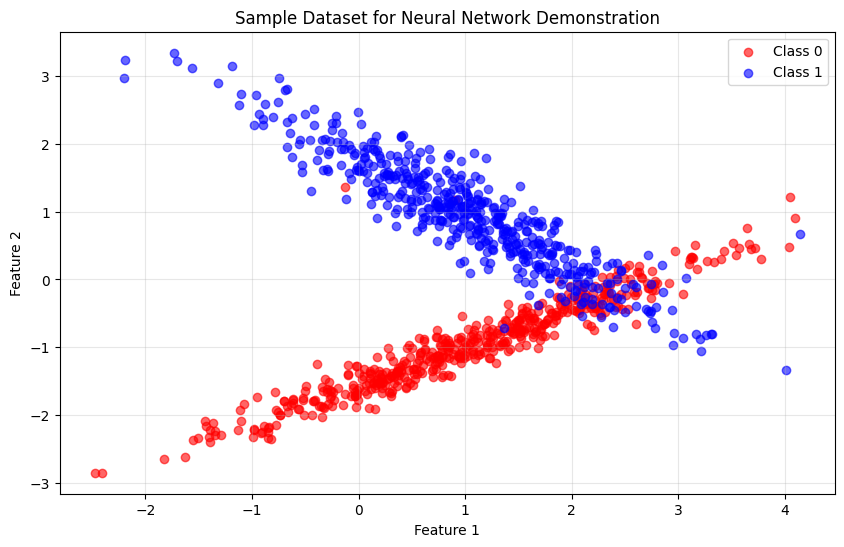


Dataset created! Now let's dive into the core concepts...


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)

print("Neural Networks: From Theory to Implementation")
print("=" * 50)
print("Setting up environment for comprehensive neural network exploration...")

# Create a simple dataset for demonstration
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                          n_informative=2, n_clusters_per_class=1, 
                          random_state=42)

print(f"Generated dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {np.unique(y)}")

# Visualize the dataset
plt.figure(figsize=(10, 6))
colors = ['red', 'blue']
for i, color in enumerate(colors):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=f'Class {i}', alpha=0.6)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sample Dataset for Neural Network Demonstration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nDataset created! Now let's dive into the core concepts...")


## The Forward Pass: How Neural Networks Make Predictions

Before diving into activation functions, let's understand exactly how data flows through a neural network to make predictions. This process is called the **forward pass** or **forward propagation**.

### What is the Forward Pass?

**Simple Definition**: The forward pass is how we feed data through the entire network, layer by layer, to get a final prediction.

**Think of it like an assembly line**: Data enters at one end, gets processed at each station (layer), and comes out as a finished product (prediction) at the other end.

### Step-by-Step Forward Pass Example

Let's walk through a complete example with real numbers. We'll predict if someone will like a movie based on two features.

#### Our Simple Network Architecture
```
Input Layer (2 neurons) → Hidden Layer (3 neurons) → Output Layer (1 neuron)
     [x₁, x₂]         →      [h₁, h₂, h₃]        →        [output]
```

#### Step 1: Input Data
```
x₁ = 8 (action scenes, scale 0-10)
x₂ = 3 (romance scenes, scale 0-10)

Input: [8, 3]
```

#### Step 2: First Layer Processing (Input → Hidden)

Each hidden neuron processes the inputs with its own weights and bias:

```
Hidden Neuron 1:
- Weights: w₁₁ = 0.5, w₁₂ = -0.2
- Bias: b₁ = 0.1
- Calculation: h₁ = (8 × 0.5) + (3 × -0.2) + 0.1 = 4.0 - 0.6 + 0.1 = 3.5
- After activation: h₁ = activation_function(3.5)

Hidden Neuron 2:
- Weights: w₂₁ = -0.3, w₂₂ = 0.8
- Bias: b₂ = 0.5
- Calculation: h₂ = (8 × -0.3) + (3 × 0.8) + 0.5 = -2.4 + 2.4 + 0.5 = 0.5
- After activation: h₂ = activation_function(0.5)

Hidden Neuron 3:
- Weights: w₃₁ = 0.7, w₃₂ = 0.1
- Bias: b₃ = -0.2
- Calculation: h₃ = (8 × 0.7) + (3 × 0.1) + (-0.2) = 5.6 + 0.3 - 0.2 = 5.7
- After activation: h₃ = activation_function(5.7)
```

Let's say our activation function is ReLU (which just keeps positive values, don't worry we'll go over these later, just understand for now that they are functions that output a value):
```
h₁ = ReLU(3.5) = 3.5
h₂ = ReLU(0.5) = 0.5  
h₃ = ReLU(5.7) = 5.7

Hidden layer output: [3.5, 0.5, 5.7]
```

#### Step 3: Final Layer Processing (Hidden → Output)

The output neuron takes the hidden layer results:

```
Output Neuron:
- Weights: w₁ = 0.3, w₂ = -0.1, w₃ = 0.4
- Bias: b = -1.0
- Calculation: z = (3.5 × 0.3) + (0.5 × -0.1) + (5.7 × 0.4) + (-1.0)
             z = 1.05 - 0.05 + 2.28 - 1.0 = 2.28
- After activation: output = activation_function(2.28)
```

If we use the sigmoid activation function for the final output:
```
output = sigmoid(2.28) ≈ 0.91
```

#### Step 4: Interpretation
```
Final prediction: 0.91 (on a scale of 0-1)
Interpretation: The model predicts this person will strongly like this movie (91% confidence)
```

### Key Insights About the Forward Pass

1. **Layer-by-layer processing**: Each layer transforms the data before passing it to the next layer
2. **Same inputs, different neurons**: Within a layer, all neurons receive the same inputs but have different weights
3. **Activation functions matter**: They determine how the linear calculations get transformed
4. **Information flows forward only**: Data moves in one direction during prediction

### Why Multiple Layers Are Powerful

**Layer 1** might learn basic patterns:
- Neuron 1: "This has high action" 
- Neuron 2: "This has balanced action/romance"
- Neuron 3: "This is action-heavy overall"

**Layer 2** combines these patterns:
- "If high action AND action-heavy overall, then strong like"

### Matrix Representation (For the Math-Curious)

The forward pass can be written compactly using matrices:

```
Layer 1: H = activation(W₁ × X + B₁)
Layer 2: Y = activation(W₂ × H + B₂)

Where:
- X = input vector [8, 3]
- W₁ = weight matrix for layer 1
- H = hidden layer activations [3.5, 0.5, 5.7]
- W₂ = weight matrix for layer 2  
- Y = final output 0.91
```

### The Forward Pass is Just the Beginning

**What we've learned**: How to make predictions with fixed weights

**What's next**: How the network learns to adjust these weights to make better predictions (that's where loss functions, gradient descent, and backpropagation come in! These are the golden core concepts that really make neural networks special!)

### Summary

- **Input processing**: Data enters the network as numbers  
- **Layer-by-layer transformation**: Each layer processes and transforms the data  
- **Parallel neuron computation**: Multiple neurons in each layer work simultaneously  
- **Activation functions**: Transform linear calculations into useful outputs  
- **Final prediction**: The last layer produces our answer  

**Coming up**: Now that you understand how predictions are made, we'll explore activation functions - the components that give each neuron its "personality" and decision-making ability!

---

## Activation Functions: The Neuron's Decision Mechanism

Now that you understand how data flows through a network, let's explore activation functions, as they are the  mathematical functions that give neurons their intelligence and decision-making power.

### What Exactly Are Activation Functions?

**Simple Definition**: An activation function is a mathematical operation applied to the output of each neuron that decides how "active" or "fired up" that neuron should be.

**The Biological Inspiration**: Real neurons in your brain don't just pass signals through linearly. They have a threshold; they only "fire" when they receive enough stimulation. Activation functions mimic this behavior.

### Why Are Activation Functions Absolutely Critical?

Let's see what happens without them:

#### Without Activation Functions (Linear Only)
```
Layer 1: h = W₁x + b₁
Layer 2: y = W₂h + b₂ = W₂(W₁x + b₁) + b₂ = W₂W₁x + W₂b₁ + b₂

- Let’s group the terms:
  - W₂W₁ is just a new weight matrix → call it W_final
  - W₂b₁ + b₂ is just a new bias vector → call it b_final

This simplifies to: y = W_final × x + b_final
```

**The Problem**: Thats literally the straight line formula (y = mx + b)! No matter how many layers you add, you still just get a single linear transformation! The network can only learn straight lines and flat planes.

#### With Activation Functions (Non-Linear)
```
Layer 1: h = activation(W₁x + b₁)
Layer 2: y = activation(W₂h + b₂)
```

Let’s try expanding it like before:
```
y = activation(W₂ × activation(W₁x + b₁) + b₂)
```

Can we simplify this?

**No.** Unlike the linear case, we can’t pull out `activation(...)` and collapse the expressions.

Why?

- The `activation()` function is **non-linear** (like ReLU, tanh, or sigmoid).
- Non-linear functions **break the ability to merge** matrix operations into a single weight+bias combo.
- You **can’t factor out** or merge `activation(W₁x + b₁)` into a neat matrix like before.

---

**So what’s the result?**

- The network becomes a **composite function**: a function *of a function* of a function, etc.
- As the network size grows, it only grows more and more complex, allowing it to be more nuanced and represent more values and possibilities.
- It can represent complex boundaries and curved decision regions, not just flat planes.
- This is what allows deep learning to work for tasks like image recognition, sentiment analysis, and more.

In short: Activation functions turn a stack of matrix math into a flexible, learnable function approximator.

**The Magic**: Now the network can learn curves, complex shapes, and intricate patterns.

### Types of Problems: Linear vs Non-Linear

**Linear Problems** (solvable without activation functions, this is actually known as LINEAR REGRESSION!):
- Predicting house price based on size (straight line relationship)
- Converting temperature from Celsius to Fahrenheit

**Non-Linear Problems** (require activation functions):
- Recognizing faces in photos
- Understanding speech
- Playing chess
- Detecting spam emails

### Properties of Good Activation Functions

1. **Non-linearity**: Must introduce curves and complexity
2. **Differentiability**: Must be smooth for learning algorithms to work
3. **Computational efficiency**: Should be fast to calculate
4. **Appropriate range**: Should produce outputs in a useful range
5. **Gradient flow**: Should allow learning signals to flow through the network (gradients should be able to travel through the network easily during backpropagation, otherwise deep learning becomes difficult, don't worry, this is covered later)

### Common Activation Functions Explained Simply

#### 1. Sigmoid Function: The Classic Smoother

**Formula**: $\sigma(z) = \frac{1}{1 + e^{-z}}$

**What it does**: Takes any number and squashes it between 0 and 1
- Input -∞: Output ≈ 0
- Input 0: Output = 0.5  
- Input +∞: Output ≈ 1

**When to use**: 
- Output layer for binary classification (yes/no decisions)
- When you need probabilities

**Real-world analogy**: Like a dimmer switch that's smooth but never completely off or on

**Pros**:
- Smooth and differentiable everywhere
- Output can be interpreted as probability
- Historically important (used in early neural networks)

**Cons**:
- **Vanishing gradients**: For very large or small inputs, the gradient becomes nearly zero
- **Not zero-centered**: Always outputs positive values
- **Saturation**: Neurons can get "stuck" at 0 or 1
- **Interpretation**: Can be interpreted as a probability

**Advantages**:
- Smooth and differentiable
- Output bounded between 0 and 1
- Clear probabilistic interpretation

**Disadvantages**:
- **Vanishing Gradient Problem**: Gradients become very small for large |z|
- **Not Zero-Centered**: Outputs are always positive
- **Saturation**: Function saturates for large inputs

**Derivative**: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

#### 2. Hyperbolic Tangent (tanh)

**Formula**: $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = \frac{2}{1 + e^{-2z}} - 1$

**Properties**:
- **Output Range**: (-1, 1)
- **Shape**: S-shaped curve, but zero-centered

**Advantages**:
- Zero-centered (mean activation closer to zero)
- Stronger gradients than sigmoid
- Smooth and differentiable

**Disadvantages**:
- Still suffers from vanishing gradient problem
- Computational overhead (exponentials)

**Derivative**: $\tanh'(z) = 1 - \tanh^2(z)$

#### 3. Rectified Linear Unit (ReLU)

**Formula**: $\text{ReLU}(z) = \max(0, z)$

**Properties**:
- **Output Range**: [0, ∞)
- **Shape**: Linear for positive inputs, zero for negative

**Advantages**:
- **Computational Efficiency**: Very fast to compute
- **Mitigates Vanishing Gradients**: Gradient is 1 for positive inputs
- **Sparse Activation**: Many neurons output zero
- **Biological Plausibility**: Similar to actual neuron behavior

**Disadvantages**:
- **Dying ReLU Problem**: Neurons can "die" (always output 0)
- **Not Differentiable at 0**: Technical issue (usually handled by subgradient)
- **Unbounded**: Output can grow arbitrarily large

**Derivative**:
$$\text{ReLU}'(z) = \begin{cases}
1 & \text{if } z > 0 \\
0 & \text{if } z < 0 \\
\text{undefined} & \text{if } z = 0
\end{cases}$$

#### 4. Leaky ReLU

**Formula**: $\text{LeakyReLU}(z) = \max(\alpha z, z)$ where $\alpha$ is a small constant (typically 0.01)

**Properties**:
- **Output Range**: (-∞, ∞)
- **Shape**: Linear with different slopes for positive and negative inputs

**Advantages**:
- Solves the dying ReLU problem
- Allows small gradients for negative inputs
- Computationally efficient

**Disadvantages**:
- Additional hyperparameter (α)
- Still unbounded

#### 5. Exponential Linear Unit (ELU)

**Formula**: 
$$\text{ELU}(z) = \begin{cases}
z & \text{if } z > 0 \\
\alpha(e^z - 1) & \text{if } z \leq 0
\end{cases}$$

**Advantages**:
- Smooth everywhere
- Mean activation closer to zero
- Avoids dying ReLU problem

**Disadvantages**:
- More expensive to compute (exponential)
- Additional hyperparameter

#### 6. Swish/SiLU (Sigmoid Linear Unit)

**Formula**: $\text{Swish}(z) = z \cdot \sigma(z) = \frac{z}{1 + e^{-z}}$

**Properties**:
- Self-gating mechanism
- Smooth and non-monotonic
- Unbounded above, bounded below

**Advantages**:
- Often outperforms ReLU in deep networks
- Smooth everywhere
- Self-normalizing properties

#### 7. GELU (Gaussian Error Linear Unit)

**Formula**: $\text{GELU}(z) = z \cdot \Phi(z)$ where $\Phi$ is the standard Gaussian CDF

**Approximation**: $\text{GELU}(z) \approx 0.5z(1 + \tanh(\sqrt{\frac{2}{\pi}}(z + 0.044715z^3)))$

**Properties**:
- Stochastic regularizer interpretation
- Smooth activation
- Popular in transformer models (GPT, BERT)

### Choosing the Right Activation Function

| Function | Hidden Layers | Output Layer (Classification) | Output Layer (Regression) |
|----------|---------------|------------------------------|---------------------------|
| **ReLU** | ✅ Default choice | ❌ Not suitable | ❌ Not suitable |
| **Leaky ReLU** | ✅ Good alternative | ❌ Not suitable | ❌ Not suitable |
| **ELU** | ✅ Good for stability | ❌ Not suitable | ❌ Not suitable |
| **Swish/GELU** | ✅ Advanced choice | ❌ Not suitable | ❌ Not suitable |
| **Sigmoid** | ❌ Vanishing gradients | ✅ Binary classification | ❌ Not suitable |
| **Tanh** | ❌ Vanishing gradients | ❌ Not suitable | ❌ Not suitable |
| **Softmax** | ❌ Not for hidden layers | ✅ Multi-class classification | ❌ Not suitable |
| **Linear** | ❌ No non-linearity | ❌ Not suitable | ✅ Regression |

### Implementation and Visualization


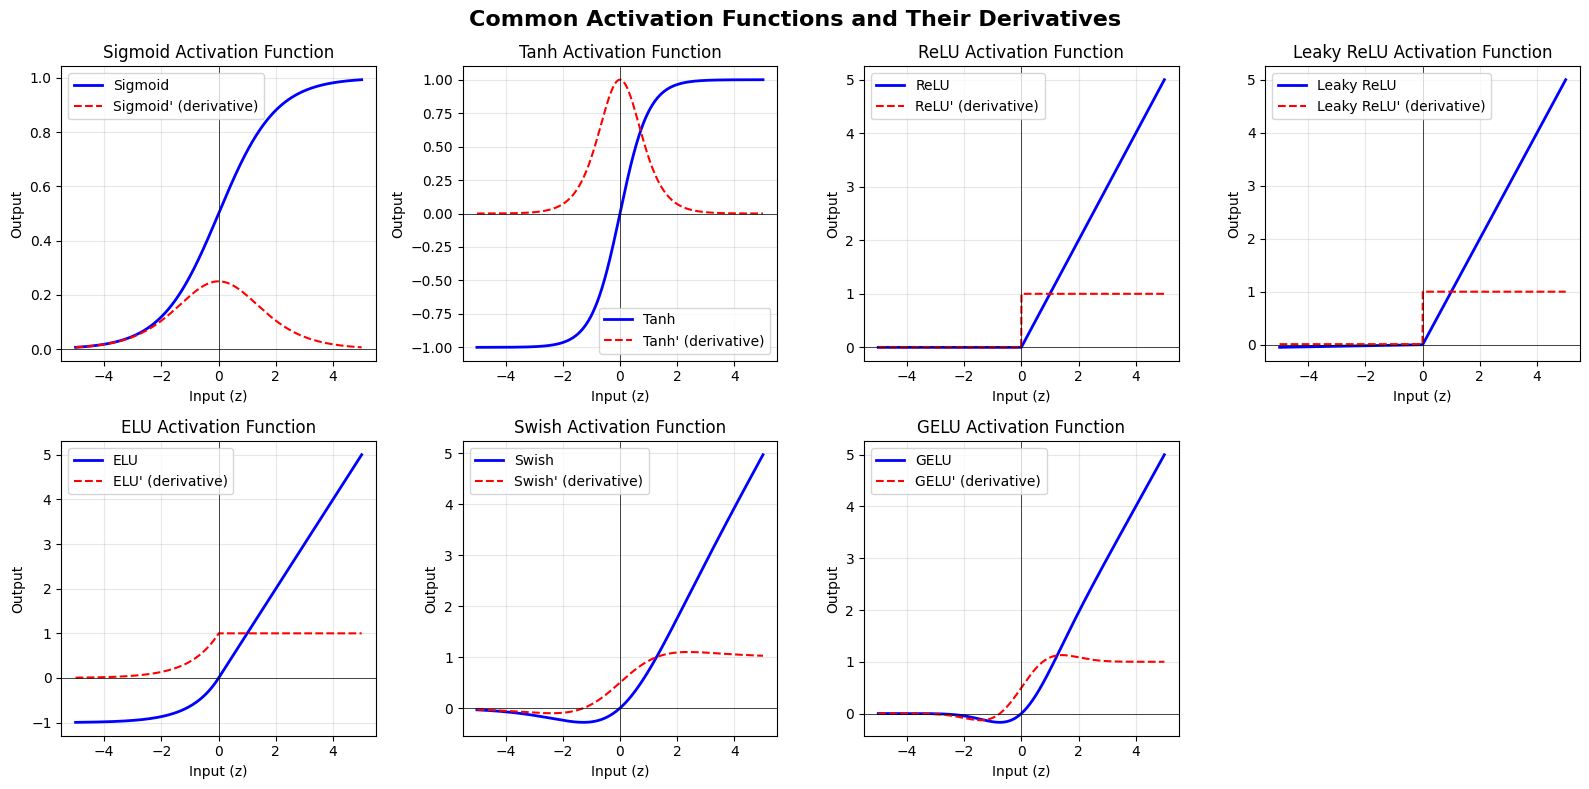


ACTIVATION FUNCTION COMPARISON
Function     Range           Main Advantage            Main Disadvantage        
-----------------------------------------------------------------------------
Sigmoid      (0, 1)          Probabilistic output      Vanishing gradients      
Tanh         (-1, 1)         Zero-centered             Vanishing gradients      
ReLU         [0, ∞)          Fast, no vanishing        Dying neurons            
Leaky ReLU   (-∞, ∞)         No dying neurons          Extra hyperparameter     
ELU          (-α, ∞)         Smooth, stable            Expensive compute        
Swish        (-∞, ∞)         Self-gating               More complex             
GELU         (-∞, ∞)         Transformer favorite      Complex computation      

VANISHING GRADIENT DEMONSTRATION
Input    Sigmoid      Tanh         ReLU         Sigmoid Grad    Tanh Grad    ReLU Grad   
-------------------------------------------------------------------------------------
-10      0.0000       -1.0000   

In [8]:
# Implementation of common activation functions
class ActivationFunctions:
    @staticmethod
    def sigmoid(z):
        """Sigmoid activation function"""
        # Clip z to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    @staticmethod
    def sigmoid_derivative(z):
        """Derivative of sigmoid function"""
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)
    
    @staticmethod
    def tanh(z):
        """Hyperbolic tangent activation function"""
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """Derivative of tanh function"""
        return 1 - np.tanh(z)**2
    
    @staticmethod
    def relu(z):
        """ReLU activation function"""
        return np.maximum(0, z)
    
    @staticmethod
    def relu_derivative(z):
        """Derivative of ReLU function"""
        return np.where(z > 0, 1.0, 0.0)
    
    @staticmethod
    def leaky_relu(z, alpha=0.01):
        """Leaky ReLU activation function"""
        return np.where(z > 0, z, alpha * z)
    
    @staticmethod
    def leaky_relu_derivative(z, alpha=0.01):
        """Derivative of Leaky ReLU function"""
        return np.where(z > 0, 1, alpha)
    
    @staticmethod
    def elu(z, alpha=1.0):
        """ELU activation function"""
        return np.where(z > 0, z, alpha * (np.exp(z) - 1))
    
    @staticmethod
    def swish(z):
        """Swish activation function"""
        return z * ActivationFunctions.sigmoid(z)
    
    @staticmethod
    def gelu(z):
        """GELU activation function (approximation)"""
        return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

# Visualize activation functions
z = np.linspace(-5, 5, 1000)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Common Activation Functions and Their Derivatives', fontsize=16, fontweight='bold')

# Function definitions for plotting
functions = [
    ('Sigmoid', ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
    ('Tanh', ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
    ('ReLU', ActivationFunctions.relu, ActivationFunctions.relu_derivative),
    ('Leaky ReLU', ActivationFunctions.leaky_relu, ActivationFunctions.leaky_relu_derivative),
    ('ELU', ActivationFunctions.elu, lambda z: np.where(z > 0, 1, ActivationFunctions.elu(z) + 1)),
    ('Swish', ActivationFunctions.swish, lambda z: ActivationFunctions.sigmoid(z) * (1 + z * (1 - ActivationFunctions.sigmoid(z)))),
    ('GELU', ActivationFunctions.gelu, lambda z: 0.5 * (1 + np.tanh(0.0356774 * z**3 + 0.797885 * z)) + (0.0535161 * z**3 + 0.398942 * z) * (1 - np.tanh(0.0356774 * z**3 + 0.797885 * z)**2))
]

# Plot functions
for i, (name, func, derivative) in enumerate(functions[:7]):
    if i < 4:
        ax = axes[0, i]
    else:
        ax = axes[1, i-4]
    
    # Plot function
    y = func(z)
    dy = derivative(z)
    
    ax.plot(z, y, 'b-', linewidth=2, label=f'{name}')
    ax.plot(z, dy, 'r--', linewidth=1.5, label=f"{name}' (derivative)")
    
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{name} Activation Function')
    ax.set_xlabel('Input (z)')
    ax.set_ylabel('Output')
    ax.legend()
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

# Remove the empty subplot
axes[1, 3].remove()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ACTIVATION FUNCTION COMPARISON")
print("="*60)
print(f"{'Function':<12} {'Range':<15} {'Main Advantage':<25} {'Main Disadvantage':<25}")
print("-"*77)
print(f"{'Sigmoid':<12} {'(0, 1)':<15} {'Probabilistic output':<25} {'Vanishing gradients':<25}")
print(f"{'Tanh':<12} {'(-1, 1)':<15} {'Zero-centered':<25} {'Vanishing gradients':<25}")
print(f"{'ReLU':<12} {'[0, ∞)':<15} {'Fast, no vanishing':<25} {'Dying neurons':<25}")
print(f"{'Leaky ReLU':<12} {'(-∞, ∞)':<15} {'No dying neurons':<25} {'Extra hyperparameter':<25}")
print(f"{'ELU':<12} {'(-α, ∞)':<15} {'Smooth, stable':<25} {'Expensive compute':<25}")
print(f"{'Swish':<12} {'(-∞, ∞)':<15} {'Self-gating':<25} {'More complex':<25}")
print(f"{'GELU':<12} {'(-∞, ∞)':<15} {'Transformer favorite':<25} {'Complex computation':<25}")

# Demonstrate the vanishing gradient problem
print("\n" + "="*60)
print("VANISHING GRADIENT DEMONSTRATION")
print("="*60)

# Show how gradients behave for different functions at extreme values
extreme_inputs = [-10, -5, -1, 0, 1, 5, 10]
print(f"{'Input':<8} {'Sigmoid':<12} {'Tanh':<12} {'ReLU':<12} {'Sigmoid Grad':<15} {'Tanh Grad':<12} {'ReLU Grad':<12}")
print("-" * 85)

for z_val in extreme_inputs:
    sig_grad = ActivationFunctions.sigmoid_derivative(z_val)
    tanh_grad = ActivationFunctions.tanh_derivative(z_val)
    relu_grad = ActivationFunctions.relu_derivative(z_val)
    
    sig_val = ActivationFunctions.sigmoid(z_val)
    tanh_val = ActivationFunctions.tanh(z_val)
    relu_val = ActivationFunctions.relu(z_val)
    
    print(f"{z_val:<8} {sig_val:<12.4f} {tanh_val:<12.4f} {relu_val:<12.4f} {sig_grad:<15.6f} {tanh_grad:<12.6f} {relu_grad:<12.1f}")

print("\nNotice how sigmoid and tanh gradients approach zero for large |z| values!")
print("This is the vanishing gradient problem - gradients become too small to update weights effectively.")
print("ReLU maintains constant gradient of 1 for positive inputs, avoiding this issue.")


## Loss Functions: Measuring Model Performance

Loss functions (also called cost functions or objective functions) quantify how well our neural network is performing. They measure the difference between predicted outputs and actual targets, providing a signal for the learning algorithm to improve.

### Why Loss Functions Matter

1. **Optimization Target**: They define what the model should optimize
2. **Performance Measurement**: They quantify how far we are from the ideal solution
3. **Gradient Source**: They provide gradients for backpropagation
4. **Task Definition**: Different tasks require different loss functions

### Properties of Good Loss Functions

1. **Differentiability**: Must be differentiable for gradient-based optimization
2. **Convexity**: Ideally convex (though neural networks are non-convex overall)
3. **Appropriate Scale**: Should provide meaningful gradients
4. **Task Alignment**: Should align with the evaluation metric we care about

### Regression Loss Functions

#### 1. Mean Squared Error (MSE)

**Formula**: 
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Properties**:
- Also called L2 loss
- Quadratic penalty for errors
- Heavily penalizes large errors

**When to Use**:
- Standard choice for regression problems
- When you want to penalize large errors more than small ones
- When outliers should be heavily penalized

**Advantages**:
- Smooth and differentiable everywhere
- Convex function
- Statistical interpretation (maximum likelihood under Gaussian noise)

**Disadvantages**:
- Sensitive to outliers
- May not be robust for noisy data

**Gradient**: $\frac{\partial \text{MSE}}{\partial \hat{y}_i} = \frac{2}{n}(\hat{y}_i - y_i)$

#### 2. Mean Absolute Error (MAE)

**Formula**: 
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Properties**:
- Also called L1 loss
- Linear penalty for errors
- More robust to outliers than MSE

**When to Use**:
- When outliers are present and shouldn't dominate
- When all errors should be weighted equally
- When you want a more robust loss function

**Advantages**:
- Robust to outliers
- Easy to interpret (average absolute deviation)
- Less sensitive to extreme values

**Disadvantages**:
- Not differentiable at zero
- May converge slowly near minimum

#### 3. Huber Loss

**Formula**: 
$$L_{\delta}(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}$$

**Properties**:
- Combines MSE and MAE
- Quadratic for small errors, linear for large errors
- Parameter δ controls the transition point

**When to Use**:
- When you want the best of both MSE and MAE
- When you have some outliers but still want smooth gradients

### Classification Loss Functions

#### 1. Binary Cross-Entropy (Log Loss)

**Formula**: 
$$\text{BCE} = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$

**Properties**:
- For binary classification (two classes)
- Outputs must be probabilities (between 0 and 1)
- Based on maximum likelihood estimation

**When to Use**:
- Binary classification problems
- When you want probabilistic outputs
- Standard choice for sigmoid output activation

**Advantages**:
- Probabilistic interpretation
- Smooth gradients
- Penalizes confident wrong predictions heavily

**Disadvantages**:
- Requires probability outputs
- Can be unstable with extreme probabilities (use numerical stability tricks)

#### 2. Categorical Cross-Entropy

**Formula**: 
$$\text{CCE} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{C} y_{ij} \log(\hat{y}_{ij})$$

**Properties**:
- For multi-class classification
- Targets are one-hot encoded
- Outputs should be probability distributions (sum to 1)

**When to Use**:
- Multi-class classification with one-hot targets
- With softmax output activation
- When classes are mutually exclusive

#### 3. Sparse Categorical Cross-Entropy

**Formula**: 
$$\text{SCCE} = -\frac{1}{n} \sum_{i=1}^{n} \log(\hat{y}_{i, y_i})$$

**Properties**:
- Same as categorical cross-entropy but with integer labels
- More memory efficient
- No need for one-hot encoding

**When to Use**:
- Multi-class classification with integer labels
- When memory is a concern
- Large number of classes

#### 4. Focal Loss

**Formula**: 
$$\text{FL} = -\alpha (1-\hat{y})^{\gamma} \log(\hat{y})$$

**Properties**:
- Addresses class imbalance
- Focuses on hard examples
- Reduces loss for well-classified examples

**When to Use**:
- Severe class imbalance
- When easy examples dominate training
- Object detection tasks

### Advanced Loss Functions

#### 1. Hinge Loss

**Formula**: 
$$L(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$

**Properties**:
- Used in Support Vector Machines
- Creates a margin between classes
- Linear beyond the margin

**When to Use**:
- When you want maximum margin classification
- Binary classification with margin
- When outliers should have bounded influence

#### 2. Triplet Loss

**Formula**: 
$$L = \max(0, d(a, p) - d(a, n) + \text{margin})$$

**Properties**:
- For learning embeddings
- Uses anchor, positive, and negative examples
- Encourages similar items to be closer

**When to Use**:
- Face recognition
- Similarity learning
- Metric learning

### Choosing the Right Loss Function

| Task Type | Recommended Loss | Output Activation | Notes |
|-----------|------------------|-------------------|-------|
| **Binary Classification** | Binary Cross-Entropy | Sigmoid | Standard choice |
| **Multi-class Classification** | Categorical Cross-Entropy | Softmax | One-hot targets |
| **Multi-class (Integer Labels)** | Sparse Categorical Cross-Entropy | Softmax | Integer targets |
| **Regression** | Mean Squared Error | Linear | Gaussian noise assumption |
| **Robust Regression** | Mean Absolute Error | Linear | Resistant to outliers |
| **Balanced Regression** | Huber Loss | Linear | Best of both worlds |
| **Imbalanced Classification** | Focal Loss | Sigmoid/Softmax | Addresses class imbalance |
| **Ranking/Similarity** | Triplet Loss | None | Learning embeddings |


LOSS FUNCTION DEMONSTRATIONS

Regression Loss Examples:
True values:      [1. 2. 3. 4. 5.]
Predicted values: [1.1 2.2 2.8 4.2 4.8]
MSE:              0.0340
MAE:              0.1800
Huber Loss:       0.0170

Binary Classification Loss Examples:
True labels:       [1 0 1 1 0]
Predicted probs:   [0.9 0.1 0.8 0.7 0.2]
Binary Cross-Entropy: 0.2027
Focal Loss:           0.0036

Outlier Sensitivity Demonstration:
Clean predictions:
MSE: 0.0100
MAE: 0.1000

With outlier (last prediction = 10.0 instead of 5.1):
MSE: 5.0080 (increased 500.8x)
MAE: 1.0800 (increased 10.8x)

Notice how MSE is much more sensitive to outliers than MAE!

Visualizing Loss Functions...


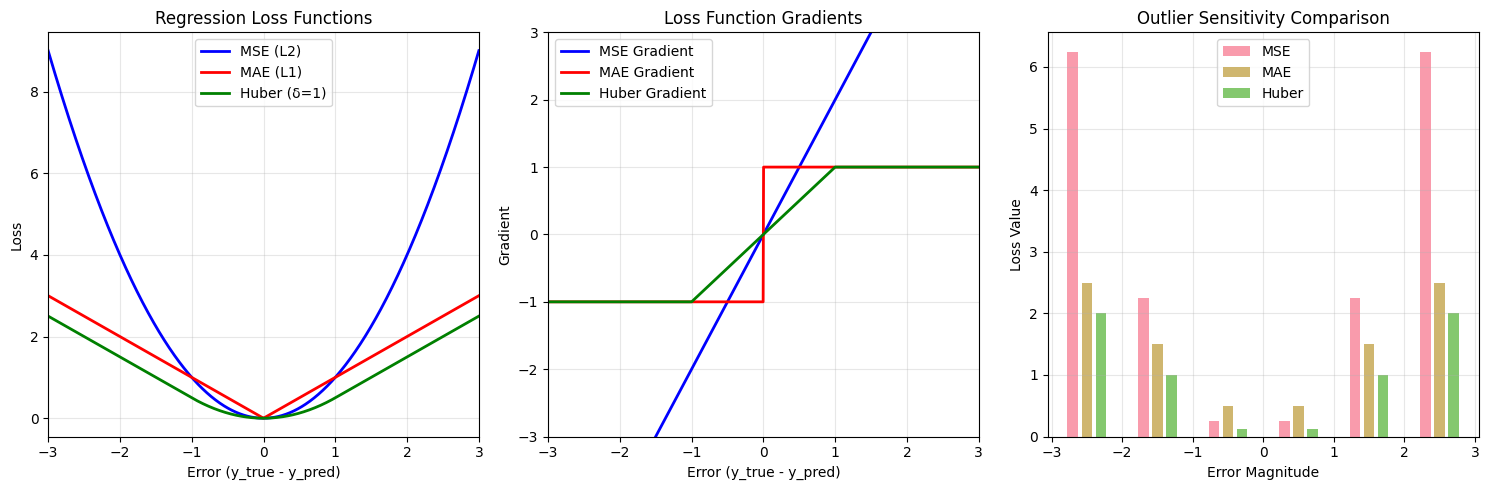

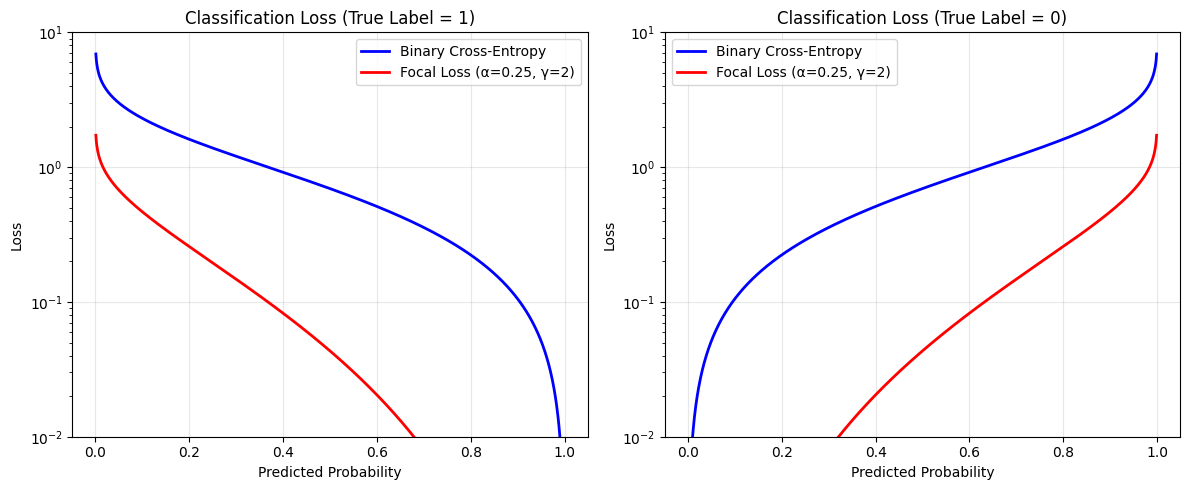


LOSS FUNCTION SELECTION GUIDE

Regression Tasks:
• MSE: Standard choice, penalizes large errors heavily
• MAE: Robust to outliers, treats all errors equally
• Huber: Best of both worlds, smooth near zero

Classification Tasks:
• Binary Cross-Entropy: Binary classification with probabilities
• Categorical Cross-Entropy: Multi-class with one-hot encoding
• Sparse Categorical: Multi-class with integer labels
• Focal Loss: Imbalanced datasets, focuses on hard examples

Special Cases:
• Hinge Loss: Maximum margin classification (SVMs)
• Triplet Loss: Learning embeddings and similarities


In [9]:
# Implementation of common loss functions
class LossFunctions:
    @staticmethod
    def mse(y_true, y_pred):
        """Mean Squared Error"""
        return np.mean((y_true - y_pred)**2)
    
    @staticmethod
    def mae(y_true, y_pred):
        """Mean Absolute Error"""
        return np.mean(np.abs(y_true - y_pred))
    
    @staticmethod
    def huber_loss(y_true, y_pred, delta=1.0):
        """Huber Loss"""
        error = y_true - y_pred
        condition = np.abs(error) <= delta
        squared_loss = 0.5 * error**2
        linear_loss = delta * np.abs(error) - 0.5 * delta**2
        return np.mean(np.where(condition, squared_loss, linear_loss))
    
    @staticmethod
    def binary_crossentropy(y_true, y_pred, epsilon=1e-15):
        """Binary Cross-Entropy"""
        # Clip predictions to prevent log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    @staticmethod
    def categorical_crossentropy(y_true, y_pred, epsilon=1e-15):
        """Categorical Cross-Entropy"""
        # Clip predictions to prevent log(0)
        y_pred = np.clip(y_pred, epsilon, 1)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
    
    @staticmethod
    def hinge_loss(y_true, y_pred):
        """Hinge Loss for binary classification"""
        return np.mean(np.maximum(0, 1 - y_true * y_pred))
    
    @staticmethod
    def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
        """Focal Loss for imbalanced classification"""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -np.mean(alpha_t * (1 - p_t)**gamma * np.log(p_t))

# Visualize how different loss functions behave
def visualize_regression_losses():
    # Create synthetic data with outliers
    errors = np.linspace(-3, 3, 1000)
    
    # Calculate different losses
    mse_losses = errors**2
    mae_losses = np.abs(errors)
    huber_losses = np.where(np.abs(errors) <= 1, 0.5 * errors**2, np.abs(errors) - 0.5)
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Loss vs Error
    plt.subplot(1, 3, 1)
    plt.plot(errors, mse_losses, 'b-', linewidth=2, label='MSE (L2)')
    plt.plot(errors, mae_losses, 'r-', linewidth=2, label='MAE (L1)')
    plt.plot(errors, huber_losses, 'g-', linewidth=2, label='Huber (δ=1)')
    plt.xlabel('Error (y_true - y_pred)')
    plt.ylabel('Loss')
    plt.title('Regression Loss Functions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(-3, 3)
    
    # Plot 2: Loss derivatives (gradients)
    plt.subplot(1, 3, 2)
    mse_grad = 2 * errors
    mae_grad = np.sign(errors)
    huber_grad = np.where(np.abs(errors) <= 1, errors, np.sign(errors))
    
    plt.plot(errors, mse_grad, 'b-', linewidth=2, label='MSE Gradient')
    plt.plot(errors, mae_grad, 'r-', linewidth=2, label='MAE Gradient')
    plt.plot(errors, huber_grad, 'g-', linewidth=2, label='Huber Gradient')
    plt.xlabel('Error (y_true - y_pred)')
    plt.ylabel('Gradient')
    plt.title('Loss Function Gradients')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    
    # Plot 3: Robustness to outliers demonstration
    plt.subplot(1, 3, 3)
    outlier_positions = np.array([-2.5, -1.5, -0.5, 0, 0.5, 1.5, 2.5])
    mse_outlier = outlier_positions**2
    mae_outlier = np.abs(outlier_positions)
    huber_outlier = np.where(np.abs(outlier_positions) <= 1, 0.5 * outlier_positions**2, 
                            np.abs(outlier_positions) - 0.5)
    
    plt.bar(outlier_positions - 0.2, mse_outlier, 0.15, label='MSE', alpha=0.7)
    plt.bar(outlier_positions, mae_outlier, 0.15, label='MAE', alpha=0.7)
    plt.bar(outlier_positions + 0.2, huber_outlier, 0.15, label='Huber', alpha=0.7)
    plt.xlabel('Error Magnitude')
    plt.ylabel('Loss Value')
    plt.title('Outlier Sensitivity Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def visualize_classification_losses():
    # For binary classification
    y_pred = np.linspace(0.001, 0.999, 1000)
    
    # True label = 1
    bce_loss_positive = -np.log(y_pred)
    focal_loss_positive = -0.25 * (1 - y_pred)**2 * np.log(y_pred)
    
    # True label = 0
    bce_loss_negative = -np.log(1 - y_pred)
    focal_loss_negative = -0.25 * y_pred**2 * np.log(1 - y_pred)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Loss when true label = 1
    plt.subplot(1, 2, 1)
    plt.plot(y_pred, bce_loss_positive, 'b-', linewidth=2, label='Binary Cross-Entropy')
    plt.plot(y_pred, focal_loss_positive, 'r-', linewidth=2, label='Focal Loss (α=0.25, γ=2)')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Loss')
    plt.title('Classification Loss (True Label = 1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.ylim(0.01, 10)
    
    # Plot 2: Loss when true label = 0
    plt.subplot(1, 2, 2)
    plt.plot(y_pred, bce_loss_negative, 'b-', linewidth=2, label='Binary Cross-Entropy')
    plt.plot(y_pred, focal_loss_negative, 'r-', linewidth=2, label='Focal Loss (α=0.25, γ=2)')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Loss')
    plt.title('Classification Loss (True Label = 0)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.ylim(0.01, 10)
    
    plt.tight_layout()
    plt.show()

# Demonstrate loss functions with synthetic data
print("LOSS FUNCTION DEMONSTRATIONS")
print("="*50)

# Regression example
np.random.seed(42)
y_true_reg = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred_reg = np.array([1.1, 2.2, 2.8, 4.2, 4.8])

print("\nRegression Loss Examples:")
print(f"True values:      {y_true_reg}")
print(f"Predicted values: {y_pred_reg}")
print(f"MSE:              {LossFunctions.mse(y_true_reg, y_pred_reg):.4f}")
print(f"MAE:              {LossFunctions.mae(y_true_reg, y_pred_reg):.4f}")
print(f"Huber Loss:       {LossFunctions.huber_loss(y_true_reg, y_pred_reg):.4f}")

# Classification example
y_true_cls = np.array([1, 0, 1, 1, 0])
y_pred_cls = np.array([0.9, 0.1, 0.8, 0.7, 0.2])

print("\nBinary Classification Loss Examples:")
print(f"True labels:       {y_true_cls}")
print(f"Predicted probs:   {y_pred_cls}")
print(f"Binary Cross-Entropy: {LossFunctions.binary_crossentropy(y_true_cls, y_pred_cls):.4f}")
print(f"Focal Loss:           {LossFunctions.focal_loss(y_true_cls, y_pred_cls):.4f}")

# Show the effect of outliers
print("\nOutlier Sensitivity Demonstration:")
print("="*40)
y_true_clean = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred_clean = np.array([1.1, 2.1, 3.1, 4.1, 5.1])
y_pred_outlier = np.array([1.1, 2.1, 3.1, 4.1, 10.0])  # Last prediction is an outlier

print("Clean predictions:")
print(f"MSE: {LossFunctions.mse(y_true_clean, y_pred_clean):.4f}")
print(f"MAE: {LossFunctions.mae(y_true_clean, y_pred_clean):.4f}")

print("\nWith outlier (last prediction = 10.0 instead of 5.1):")
print(f"MSE: {LossFunctions.mse(y_true_clean, y_pred_outlier):.4f} (increased {LossFunctions.mse(y_true_clean, y_pred_outlier)/LossFunctions.mse(y_true_clean, y_pred_clean):.1f}x)")
print(f"MAE: {LossFunctions.mae(y_true_clean, y_pred_outlier):.4f} (increased {LossFunctions.mae(y_true_clean, y_pred_outlier)/LossFunctions.mae(y_true_clean, y_pred_clean):.1f}x)")

print("\nNotice how MSE is much more sensitive to outliers than MAE!")

# Visualize loss functions
print("\nVisualizing Loss Functions...")
visualize_regression_losses()
visualize_classification_losses()

print("\n" + "="*60)
print("LOSS FUNCTION SELECTION GUIDE")
print("="*60)
print("\nRegression Tasks:")
print("• MSE: Standard choice, penalizes large errors heavily")
print("• MAE: Robust to outliers, treats all errors equally")
print("• Huber: Best of both worlds, smooth near zero")
print("\nClassification Tasks:")
print("• Binary Cross-Entropy: Binary classification with probabilities")
print("• Categorical Cross-Entropy: Multi-class with one-hot encoding")
print("• Sparse Categorical: Multi-class with integer labels")
print("• Focal Loss: Imbalanced datasets, focuses on hard examples")
print("\nSpecial Cases:")
print("• Hinge Loss: Maximum margin classification (SVMs)")
print("• Triplet Loss: Learning embeddings and similarities")


## Gradient Descent: The Optimization Engine

Gradient descent is the fundamental optimization algorithm that powers neural network training. It's the mechanism by which neural networks learn. They iteratively adjust weights to minimize the loss function.

### The Core Intuition

Imagine you're blindfolded on a hillside and want to reach the bottom (minimum). Your strategy would be:
1. Feel the slope around you
2. Take a step in the direction of steepest descent
3. Repeat until you reach the bottom

This is exactly what gradient descent does, but in high-dimensional parameter space.

### Mathematical Foundation: Gradients and Learning

When training a neural network, we want to minimize a **loss function**—a mathematical expression of how wrong the model is. To do this, we use **gradient descent**, which tells us how to adjust each parameter (like weights) to reduce the loss.

#### What is a Gradient?

The **gradient** is a vector that points in the direction of the **steepest increase** of a function. Since we want to **minimize** the loss, we move in the **opposite** direction of the gradient.

This works because—most of the time—the steepest increase direction is also near the steepest descent in the opposite direction. So by going against the gradient, we typically head "downhill" efficiently.

For a function $f(\mathbf{w})$, where $\mathbf{w} = [w_1, w_2, \ldots, w_n]$ (a vector of weights), the gradient looks like this:

$$\nabla f(\mathbf{w}) = \left[\frac{\partial f}{\partial w_1}, \frac{\partial f}{\partial w_2}, \ldots, \frac{\partial f}{\partial w_n}\right]$$

This tells us how sensitive the loss is to each parameter.

#### Gradient Descent Update Rule

To update weights during training, we use:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha \nabla f(\mathbf{w}^{(t)})$$

Where:
- $\mathbf{w}^{(t)}$ is the parameter vector (vector containing all the weights) at iteration/step $t$
- $\nabla f(\mathbf{w}^{(t)})$ = gradient of the loss at the current weights/parameters
- $\alpha$ = **learning rate** (also called **step size**)

#### What's the Learning Rate?

The **learning rate** $\alpha$ is a small positive number that controls **how big of a step** we take in the direction opposite the gradient.

- If it's **too small**, training is very slow.
- If it's **too large**, the model might overshoot the minimum and never converge.

In simple terms:  
**The gradient gives the direction** to move all the weights in,  
**The learning rate decides how far** to move in that direction.

This step-by-step update continues until the model reaches a point where the loss is low enough (ideally a minimum).

#### Visual Intuition for this

Think of the loss surface as a giant **3D landscape** of hills and valleys, where:

- Each point represents a set of weights
- The height represents the **loss** (how bad the model is)

Your goal is to reach the lowest point in this landscape (the valley of minimum loss).

(3D would apply to weight vectors that contain 3 weights only. This makes it easy to visualize. We can't draw in higher than 3 dimensions, but for weight vectors that contain more than 3 weights, you can simply just apply this intuition/analogy to see why it works. The 3D version works and is easy to visualize, so you just have to apply it to higher dimensions.)

Now imagine you're standing on this landscape, blindfolded, with your feet on the surface. You use your hands to **feel the slope beneath you**. This is exactly the information the calculated **gradient** tells you.

- If the slope is steep downhill, the gradient is large → take a big step.
- If the slope is shallow, the gradient is small → take a smaller step.
- You always step **downhill**, in the direction that lowers the loss the fastest (i.e., opposite the steepest ascent).

This is exactly what gradient descent does:  
It follows the slope of the terrain **downhill**, one small step at a time, adjusting your direction as the slope changes beneath your feet.

It follows the rule, that in most scenarios, the direction directly opposite the steepest ascent typically tends to have the steepest descent! This is an accepted and followed strategy as steepest descents tend to be directly opposite steepest ascents! However, there is a caveat to this.

#### What if the surface is flat?
What can happen, is that you might know what the steepest ascent is. However, directly opposite to it, instead of being steep descent, the ground is just flat. Everywhere around is flat aside from this steep ascent in front of you.

You can also just have scenario where the ground around you is ENTIRELY flat. Basically flat in all directions, 360 degrees.

These are called **plateaus**.

- The gradient becomes extremely small (near-zero)
- The model barely updates
- Training **slows down drastically**

This is one reason why **optimizers** (like Adam or RMSProp) were introduced: to help push through flat zones. (Don’t worry, we cover optimizers later.)

### Types of Gradient Descent
There are different types of gradient descent. All types of gradient descent aim to minimize the same loss function (same 3D surface), but they differ in how they calculate the slope beneath their feet, whether they use the full dataset (Survey the entire terrain), a single example (Based on that one rock’s slope, you decide where to step.), or a small batch (Look at a chunk of the terrain), to decide which direction to move.

#### 1. Batch Gradient Descent (BGD)

It's worth mentioning what an epoch is at this point. An **epoch** is one complete pass through the entire training dataset (so one complete pass through the dataset where you feed each row/sample of the dataset into the network once for training).

**Algorithm**:
- Compute gradient using **all** training examples
  - This means we take every example in the dataset, compute how much each one contributes to the overall loss, and average those gradients.
  - Imagine a high-dimensional loss surface, where every point’s slope (gradient) depends on all the data, you’re calculating the overall “steepest descent” direction based on the full dataset.
- Update parameters once per epoch

**Formula**:
$$\nabla J(\mathbf{w}) = \frac{1}{m} \sum_{i=1}^{m} \nabla J_i(\mathbf{w})$$
- The gradient of the overall loss function J(w) is the average of the gradients from each data point’s individual loss Jᵢ(w).
- Each $\nabla J_i(\mathbf{w})$ gives the direction that particular training example wants the weights to move. You average them to get a global direction.


**Advantages**:
- Guaranteed convergence to global minimum (for convex functions)
- Stable convergence
- Exact gradient computation

**Disadvantages**:
- Slow for large datasets
- Memory intensive
- No online learning capability

#### 2. Stochastic Gradient Descent (SGD)

**Algorithm**:
- Compute gradient using **one** training example at a time
- Update parameters after each example

**Formula**:
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha \nabla J_i(\mathbf{w}^{(t)})$$

- i is the index of s specific random training example that is used to compute the gradient at each step.
- $\nabla J_i(\mathbf{w})$ is the direction that just one data point thinks the weights should move.
- Since it’s based on a single example, this gradient is noisy, it may not represent the direction that reduces the total loss best.
- But by taking many such small, fast steps, SGD often still finds a good minimum over time.
- Think of it as getting frequent, fast-but-imprecise updates from different perspectives.
- Remember the rock analogy? Based on that one rock’s slope, you decide where to step. It’s fast, but noisy,sometimes the rock fools you, and you step the wrong way.

**Advantages**:
- Fast updates
- Can escape local minima (due to noise)
- Online learning capability
- Memory efficient

**Disadvantages**:
- Noisy convergence
- May not converge to exact minimum
- Requires learning rate scheduling

#### 3. Mini-Batch Gradient Descent

**Algorithm**:
- Compute gradient using a small batch of examples (typically 32-512)
- Best of both worlds approach

**Formula**:
$$\nabla J(\mathbf{w}) = \frac{1}{|B|} \sum_{i \in B} \nabla J_i(\mathbf{w})$$

Where $B$ is the mini-batch and $|B|$ is the batch size.

- Instead of using all data (like BGD) or just one data point (like SGD), mini-batch uses a subset of the data at each step.
- Each example in the mini-batch gives its own gradient $\nabla J_i(\mathbf{w})$.
- These are averaged to produce a smoothed estimate of the gradient.
- This balances the speed of SGD with the stability of BGD.
- Common batch sizes are 32, 64, or 128, depending on memory and task.

**Advantages**:
- More stable than SGD
- Faster than BGD
- Efficient use of vectorized operations
- Good balance of speed and stability

**Disadvantages**:
- Additional hyperparameter (batch size)
- Still has some noise

### Advanced Optimization Algorithms

#### 1. Momentum

**Intuition**: Remember previous gradients to smooth out oscillations and accelerate convergence.

**Formula**:
$$\mathbf{v}^{(t)} = \beta \mathbf{v}^{(t-1)} + (1-\beta) \nabla J(\mathbf{w}^{(t)})$$
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha \mathbf{v}^{(t)}$$

Where $\beta$ is the momentum coefficient (typically 0.9).

**Advantages**:
- Faster convergence
- Better handling of ill-conditioned problems
- Reduced oscillations

#### 2. Adaptive Learning Rate Methods

**RMSprop**:
$$\mathbf{s}^{(t)} = \beta \mathbf{s}^{(t-1)} + (1-\beta) (\nabla J(\mathbf{w}^{(t)}))^2$$
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\alpha}{\sqrt{\mathbf{s}^{(t)} + \epsilon}} \nabla J(\mathbf{w}^{(t)})$$

**Adam** (Adaptive Moment Estimation):
$$\mathbf{m}^{(t)} = \beta_1 \mathbf{m}^{(t-1)} + (1-\beta_1) \nabla J(\mathbf{w}^{(t)})$$
$$\mathbf{v}^{(t)} = \beta_2 \mathbf{v}^{(t-1)} + (1-\beta_2) (\nabla J(\mathbf{w}^{(t)}))^2$$
$$\hat{\mathbf{m}}^{(t)} = \frac{\mathbf{m}^{(t)}}{1-\beta_1^t}, \quad \hat{\mathbf{v}}^{(t)} = \frac{\mathbf{v}^{(t)}}{1-\beta_2^t}$$
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\alpha}{\sqrt{\hat{\mathbf{v}}^{(t)}} + \epsilon} \hat{\mathbf{m}}^{(t)}$$

**Advantages of Adam**:
- Combines benefits of momentum and RMSprop
- Adaptive learning rates for each parameter
- Works well in practice for many problems
- Requires minimal hyperparameter tuning

### Learning Rate: The Critical Hyperparameter

The learning rate $\alpha$ controls the step size of gradient descent.

#### Learning Rate Effects

**Too Small** ($\alpha$ too small):
- Slow convergence
- May get stuck in local minima
- Training takes very long

**Too Large** ($\alpha$ too large):
- Overshooting the minimum
- Oscillations around minimum
- Divergence (loss increases)

**Just Right**:
- Smooth, steady convergence
- Reaches minimum efficiently
- Stable training

#### Learning Rate Scheduling

**Step Decay**:
$$\alpha^{(t)} = \alpha_0 \cdot \gamma^{\lfloor t/s \rfloor}$$

**Exponential Decay**:
$$\alpha^{(t)} = \alpha_0 e^{-\lambda t}$$

**Cosine Annealing**:
$$\alpha^{(t)} = \alpha_{min} + \frac{1}{2}(\alpha_{max} - \alpha_{min})(1 + \cos(\frac{t}{T}\pi))$$

### Common Challenges and Solutions

#### 1. Local Minima
- **Problem**: Getting stuck in suboptimal solutions
- **Solutions**: Momentum, random restarts, different initializations

#### 2. Saddle Points
- **Problem**: Points where gradient is zero but not a minimum
- **Solutions**: Momentum, adaptive methods, noise injection

#### 3. Vanishing/Exploding Gradients
- **Problem**: Gradients become too small or too large
- **Solutions**: Gradient clipping, proper initialization, batch normalization

#### 4. Plateau Regions
- **Problem**: Very flat regions with small gradients
- **Solutions**: Adaptive learning rates, momentum, learning rate scheduling

### Gradient Descent in Neural Networks

In neural networks, gradient descent optimizes the weights $\mathbf{W}$ and biases $\mathbf{b}$ across all layers:

$$\mathbf{W}^{[l](t+1)} = \mathbf{W}^{[l](t)} - \alpha \frac{\partial J}{\partial \mathbf{W}^{[l]}}$$
$$\mathbf{b}^{[l](t+1)} = \mathbf{b}^{[l](t)} - \alpha \frac{\partial J}{\partial \mathbf{b}^{[l]}}$$

The gradients $\frac{\partial J}{\partial \mathbf{W}^{[l]}}$ and $\frac{\partial J}{\partial \mathbf{b}^{[l]}}$ are computed using **backpropagation**, which we'll cover in the next section.

### Choosing the Right Optimizer

| Optimizer | When to Use | Advantages | Disadvantages |
|-----------|-------------|------------|---------------|
| **SGD** | Simple problems, when you want control | Simple, well understood | Requires manual tuning |
| **SGD + Momentum** | Most traditional ML problems | Good convergence, stable | Still requires tuning |
| **Adam** | Default choice for deep learning | Adaptive, works well out-of-the-box | Can overshoot, memory overhead |
| **RMSprop** | RNNs, non-stationary problems | Good for non-stationary objectives | Can be unstable |
| **AdaGrad** | Sparse data, NLP | Good for sparse features | Learning rate decays too aggressively |

### Best Practices

1. **Start with Adam**: Often works well with default parameters
2. **Learning Rate**: Start with 0.001, adjust based on performance
3. **Batch Size**: Powers of 2 (32, 64, 128, 256) for efficiency
4. **Monitor Loss**: Plot training loss to debug optimization
5. **Learning Rate Scheduling**: Reduce learning rate when loss plateaus
6. **Early Stopping**: Stop training when validation loss stops improving


GRADIENT DESCENT IMPLEMENTATIONS AND VISUALIZATIONS

1. Optimizing the Rosenbrock Function:
The Rosenbrock function is a classic test case for optimization algorithms.
It has a global minimum at (1, 1) but is challenging due to its banana-shaped valley.
SGD: Final point = (-0.8121, 0.6675), Function value = 3.290096
SGD + Momentum: Final point = (0.9913, 0.9826), Function value = 0.000076
Adam: Final point = (-0.1007, 0.0107), Function value = 1.211582


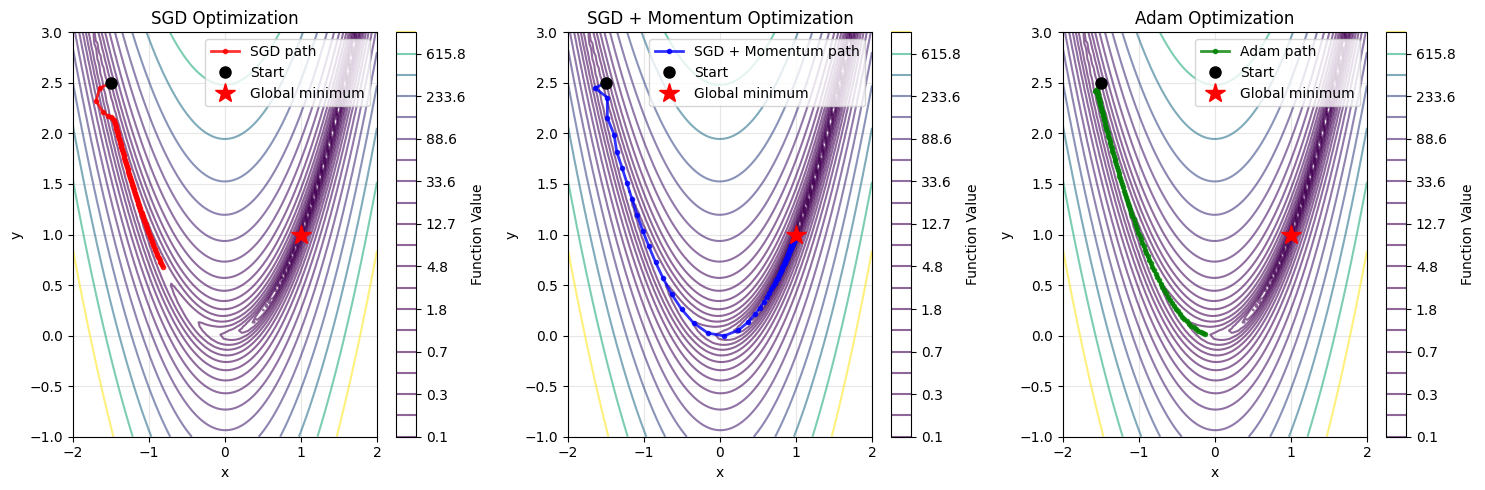


2. Effect of Learning Rate:
Learning rate controls the step size in gradient descent.
Too small = slow convergence, too large = oscillation/divergence


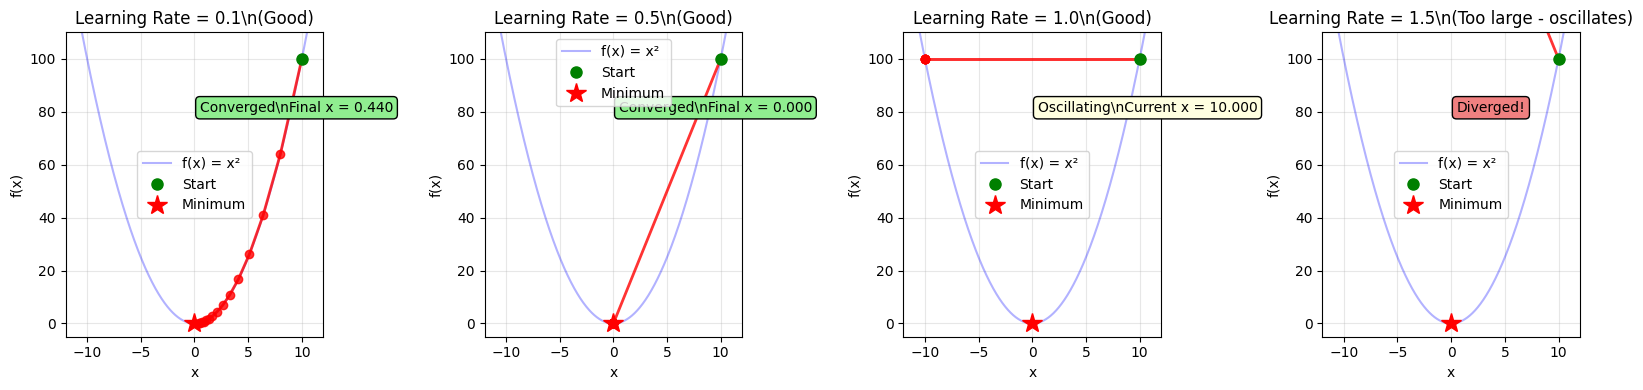


KEY INSIGHTS FROM VISUALIZATIONS

✓ SGD: Simple but can be slow, especially in valleys
✓ SGD + Momentum: Accelerates through valleys, reduces oscillations
✓ Adam: Adaptive learning rates, often converges fastest
✓ Learning Rate: Critical hyperparameter - too large causes instability
✓ Path Shape: Different optimizers take different routes to the minimum

PRACTICAL RECOMMENDATIONS

1. Start with Adam optimizer (lr=0.001) for most problems
2. Use learning rate scheduling if training plateaus
3. Monitor loss curves to detect optimization issues
4. SGD + Momentum is more stable for fine-tuning
5. Batch size affects convergence: larger = more stable but slower


In [10]:
# Implementation of gradient descent optimizers
class Optimizers:
    @staticmethod
    def sgd(params, grads, learning_rate):
        """Standard SGD update"""
        for param, grad in zip(params, grads):
            param -= learning_rate * grad
    
    @staticmethod
    def sgd_momentum(params, grads, velocities, learning_rate, momentum=0.9):
        """SGD with momentum"""
        for param, grad, velocity in zip(params, grads, velocities):
            velocity[:] = momentum * velocity + learning_rate * grad
            param -= velocity
    
    @staticmethod
    def adam(params, grads, m_values, v_values, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8, t=1):
        """Adam optimizer"""
        for param, grad, m, v in zip(params, grads, m_values, v_values):
            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * grad**2
            
            # Bias correction
            m_corrected = m / (1 - beta1**t)
            v_corrected = v / (1 - beta2**t)
            
            param -= learning_rate * m_corrected / (np.sqrt(v_corrected) + epsilon)

# Visualize gradient descent on a simple 2D function
def rosenbrock(x, y):
    """Rosenbrock function - a classic optimization test function"""
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_gradient(x, y):
    """Gradient of Rosenbrock function"""
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

def visualize_gradient_descent():
    """Visualize different optimization algorithms on Rosenbrock function"""
    
    # Create meshgrid for contour plot
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = rosenbrock(X, Y)
    
    # Starting point
    start_point = np.array([-1.5, 2.5])
    
    # Different optimizers
    optimizers = {
        'SGD': {'lr': 0.001, 'color': 'red'},
        'SGD + Momentum': {'lr': 0.001, 'momentum': 0.9, 'color': 'blue'},
        'Adam': {'lr': 0.01, 'color': 'green'}
    }
    
    plt.figure(figsize=(15, 5))
    
    for i, (name, config) in enumerate(optimizers.items(), 1):
        plt.subplot(1, 3, i)
        
        # Plot contour
        plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), alpha=0.6)
        plt.colorbar(label='Function Value')
        
        # Run optimization
        point = start_point.copy()
        path = [point.copy()]
        
        if name == 'SGD':
            for step in range(1000):
                grad = rosenbrock_gradient(point[0], point[1])
                point -= config['lr'] * grad
                if step % 10 == 0:  # Record every 10th step
                    path.append(point.copy())
                if np.linalg.norm(grad) < 1e-6:
                    break
                    
        elif name == 'SGD + Momentum':
            velocity = np.zeros_like(point)
            for step in range(1000):
                grad = rosenbrock_gradient(point[0], point[1])
                velocity = config['momentum'] * velocity + config['lr'] * grad
                point -= velocity
                if step % 10 == 0:
                    path.append(point.copy())
                if np.linalg.norm(grad) < 1e-6:
                    break
                    
        elif name == 'Adam':
            m = np.zeros_like(point)
            v = np.zeros_like(point)
            beta1, beta2 = 0.9, 0.999
            for step in range(1000):
                t = step + 1
                grad = rosenbrock_gradient(point[0], point[1])
                
                m = beta1 * m + (1 - beta1) * grad
                v = beta2 * v + (1 - beta2) * grad**2
                
                m_corrected = m / (1 - beta1**t)
                v_corrected = v / (1 - beta2**t)
                
                point -= config['lr'] * m_corrected / (np.sqrt(v_corrected) + 1e-8)
                
                if step % 10 == 0:
                    path.append(point.copy())
                if np.linalg.norm(grad) < 1e-6:
                    break
        
        # Plot optimization path
        path = np.array(path)
        plt.plot(path[:, 0], path[:, 1], 'o-', color=config['color'], 
                linewidth=2, markersize=3, alpha=0.8, label=f'{name} path')
        plt.plot(start_point[0], start_point[1], 'ko', markersize=8, label='Start')
        plt.plot(1, 1, 'r*', markersize=15, label='Global minimum')
        
        plt.title(f'{name} Optimization')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Print final point
        print(f"{name}: Final point = ({point[0]:.4f}, {point[1]:.4f}), "
              f"Function value = {rosenbrock(point[0], point[1]):.6f}")
    
    plt.tight_layout()
    plt.show()

# Demonstrate learning rate effects
def demonstrate_learning_rates():
    """Show the effect of different learning rates"""
    
    # Simple quadratic function: f(x) = x^2
    def simple_function(x):
        return x**2
    
    def simple_gradient(x):
        return 2 * x
    
    learning_rates = [0.1, 0.5, 1.0, 1.5]
    start_x = 10.0
    
    plt.figure(figsize=(16, 4))
    
    for i, lr in enumerate(learning_rates, 1):
        plt.subplot(1, 4, i)
        
        # Plot function
        x_range = np.linspace(-12, 12, 1000)
        y_range = simple_function(x_range)
        plt.plot(x_range, y_range, 'b-', alpha=0.3, label='f(x) = x²')
        
        # Run gradient descent
        x = start_x
        path_x, path_y = [], []
        
        for step in range(15):  # Limited steps to show behavior
            path_x.append(x)
            path_y.append(simple_function(x))
            
            grad = simple_gradient(x)
            x = x - lr * grad
            
            # Stop if converged or diverged
            if abs(x) > 50:
                break
        
        # Plot optimization path
        plt.plot(path_x, path_y, 'ro-', markersize=6, linewidth=2, alpha=0.8)
        plt.plot(start_x, simple_function(start_x), 'go', markersize=8, label='Start')
        plt.plot(0, 0, 'r*', markersize=15, label='Minimum')
        
        if lr <= 1.0:
            plt.title(f'Learning Rate = {lr}\\n(Good)')
        else:
            plt.title(f'Learning Rate = {lr}\\n(Too large - oscillates)')
            
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(-12, 12)
        plt.ylim(-5, 110)
        
        # Add annotations
        if len(path_x) > 1:
            final_x = path_x[-1]
            if abs(final_x) < 1:
                plt.text(0.5, 80, f'Converged\\nFinal x = {final_x:.3f}', 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
            elif abs(final_x) > 20:
                plt.text(0.5, 80, 'Diverged!', 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
            else:
                plt.text(0.5, 80, f'Oscillating\\nCurrent x = {final_x:.3f}', 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
    
    plt.tight_layout()
    plt.show()

print("GRADIENT DESCENT IMPLEMENTATIONS AND VISUALIZATIONS")
print("="*60)

print("\n1. Optimizing the Rosenbrock Function:")
print("The Rosenbrock function is a classic test case for optimization algorithms.")
print("It has a global minimum at (1, 1) but is challenging due to its banana-shaped valley.")
visualize_gradient_descent()

print("\n2. Effect of Learning Rate:")
print("Learning rate controls the step size in gradient descent.")
print("Too small = slow convergence, too large = oscillation/divergence")
demonstrate_learning_rates()

print("\n" + "="*60)
print("KEY INSIGHTS FROM VISUALIZATIONS")
print("="*60)
print("\n✓ SGD: Simple but can be slow, especially in valleys")
print("✓ SGD + Momentum: Accelerates through valleys, reduces oscillations")
print("✓ Adam: Adaptive learning rates, often converges fastest")
print("✓ Learning Rate: Critical hyperparameter - too large causes instability")
print("✓ Path Shape: Different optimizers take different routes to the minimum")

print("\n" + "="*60)
print("PRACTICAL RECOMMENDATIONS")
print("="*60)
print("\n1. Start with Adam optimizer (lr=0.001) for most problems")
print("2. Use learning rate scheduling if training plateaus")
print("3. Monitor loss curves to detect optimization issues")
print("4. SGD + Momentum is more stable for fine-tuning")
print("5. Batch size affects convergence: larger = more stable but slower")


## Backpropagation: How Neural Networks Learn

Backpropagation is the fundamental algorithm that makes neural network training possible. It efficiently computes gradients of the loss function with respect to all parameters in the network using the chain rule of calculus.

### The Learning Problem

**Goal**: Minimize the loss function $J(\mathbf{W}, \mathbf{b})$ by finding optimal weights and biases.

**Challenge**: Neural networks have millions of parameters across multiple layers. How do we compute gradients efficiently?

**Solution**: Backpropagation uses the chain rule to compute gradients layer by layer, working backwards from the output.

### Mathematical Foundation: The Chain Rule

The chain rule is the mathematical foundation of backpropagation. For a composite function:

$$\frac{\partial}{\partial x} f(g(x)) = f'(g(x)) \cdot g'(x)$$

In neural networks, the loss is a composite function of many layers:

$$J = f^{[L]}(f^{[L-1]}(...f^{[2]}(f^{[1]}(\mathbf{x}))))$$

Where $f^{[l]}$ represents the computation in layer $l$.

### Forward Propagation: Computing Predictions

Before backpropagation, we need forward propagation to compute the network's output.

**For each layer $l$**:
1. **Linear transformation**: $\mathbf{Z}^{[l]} = \mathbf{W}^{[l]} \mathbf{A}^{[l-1]} + \mathbf{b}^{[l]}$
2. **Activation**: $\mathbf{A}^{[l]} = g^{[l]}(\mathbf{Z}^{[l]})$

Where:
- $\mathbf{A}^{[0]} = \mathbf{X}$ (input)
- $g^{[l]}$ is the activation function for layer $l$
- $\mathbf{A}^{[L]}$ is the final output (predictions)

### Backward Propagation: Computing Gradients

Backpropagation computes gradients by working backwards from the loss to each parameter.

#### Step 1: Output Layer Gradient

For the output layer $L$:

$$\frac{\partial J}{\partial \mathbf{Z}^{[L]}} = \frac{\partial J}{\partial \mathbf{A}^{[L]}} \odot g'^{[L]}(\mathbf{Z}^{[L]})$$

Where $\odot$ denotes element-wise multiplication.

#### Step 2: Hidden Layer Gradients

For hidden layers $l = L-1, L-2, ..., 1$:

$$\frac{\partial J}{\partial \mathbf{Z}^{[l]}} = (\mathbf{W}^{[l+1]})^T \frac{\partial J}{\partial \mathbf{Z}^{[l+1]}} \odot g'^{[l]}(\mathbf{Z}^{[l]})$$

#### Step 3: Parameter Gradients

For weights and biases in layer $l$:

$$\frac{\partial J}{\partial \mathbf{W}^{[l]}} = \frac{1}{m} \frac{\partial J}{\partial \mathbf{Z}^{[l]}} (\mathbf{A}^{[l-1]})^T$$

$$\frac{\partial J}{\partial \mathbf{b}^{[l]}} = \frac{1}{m} \sum_{i=1}^{m} \frac{\partial J}{\partial \mathbf{Z}^{[l]}}$$

Where $m$ is the batch size.

### Detailed Backpropagation Algorithm

**Input**: Training data $(\mathbf{X}, \mathbf{Y})$, network parameters $\{\mathbf{W}^{[l]}, \mathbf{b}^{[l]}\}$

**Algorithm**:

1. **Forward Pass**:
   ```
   for l = 1 to L:
       Z[l] = W[l] @ A[l-1] + b[l]
       A[l] = activation[l](Z[l])
   ```

2. **Compute Loss**:
   ```
   J = loss_function(A[L], Y)
   ```

3. **Backward Pass**:
   ```
   # Output layer
   dZ[L] = A[L] - Y  # For cross-entropy + softmax
   
   for l = L down to 1:
       # Parameter gradients
       dW[l] = (1/m) * dZ[l] @ A[l-1].T
       db[l] = (1/m) * sum(dZ[l], axis=1)
       
       # Gradient for previous layer (if not input layer)
       if l > 1:
           dA[l-1] = W[l].T @ dZ[l]
           dZ[l-1] = dA[l-1] * activation_derivative[l-1](Z[l-1])
   ```

4. **Update Parameters**:
   ```
   for l = 1 to L:
       W[l] = W[l] - learning_rate * dW[l]
       b[l] = b[l] - learning_rate * db[l]
   ```

### Why Backpropagation Works

#### Efficiency
- **Without backpropagation**: Computing gradients would require $O(|\\text{parameters}|^2)$ operations
- **With backpropagation**: Only $O(|\\text{parameters}|)$ operations needed
- **Key insight**: Gradients can be computed in a single backward pass through the network

#### Automatic Differentiation
- Backpropagation is a form of automatic differentiation
- The computational graph naturally encodes the chain rule
- Each operation knows how to compute its local gradient

### Common Backpropagation Scenarios

#### 1. Regression with MSE Loss

**Forward**: $\hat{y} = \mathbf{W} \mathbf{x} + b$, $J = \frac{1}{2}(y - \hat{y})^2$

**Backward**: $\frac{\partial J}{\partial \hat{y}} = -(y - \hat{y})$

#### 2. Binary Classification with Sigmoid + BCE

**Forward**: $\hat{y} = \sigma(\mathbf{W} \mathbf{x} + b)$, $J = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$

**Backward**: $\frac{\partial J}{\partial z} = \hat{y} - y$ (where $z$ is pre-activation)

#### 3. Multi-class Classification with Softmax + CCE

**Forward**: $\hat{\mathbf{y}} = \\text{softmax}(\mathbf{W} \mathbf{x} + \mathbf{b})$

**Backward**: $\frac{\partial J}{\partial \mathbf{z}} = \hat{\mathbf{y}} - \mathbf{y}$ (where $\mathbf{z}$ is pre-activation vector)

### Computational Graph Perspective

Neural networks can be viewed as computational graphs where:
- **Nodes** represent operations (matrix multiplication, activation functions, loss)
- **Edges** represent data flow
- **Forward pass** computes values flowing from input to output
- **Backward pass** computes gradients flowing from output to input

### Challenges and Solutions

#### 1. Vanishing Gradients

**Problem**: Gradients become exponentially small in deep networks
$$\frac{\partial J}{\partial \mathbf{W}^{[1]}} = \frac{\partial J}{\partial \mathbf{A}^{[L]}} \prod_{l=2}^{L} \mathbf{W}^{[l]} \prod_{l=1}^{L} g'^{[l]}(\mathbf{Z}^{[l]})$$

**Solutions**:
- Use ReLU activations (gradient = 1 for positive inputs)
- Proper weight initialization (Xavier/He initialization)
- Batch normalization
- Residual connections (skip connections)
- LSTM/GRU for sequential data

#### 2. Exploding Gradients

**Problem**: Gradients become exponentially large

**Solutions**:
- Gradient clipping: $\\text{clip}(\nabla, \\text{threshold})$
- Proper weight initialization
- Batch normalization
- Lower learning rates

#### 3. Dead Neurons

**Problem**: Neurons always output zero (especially with ReLU)

**Solutions**:
- Use Leaky ReLU or ELU
- Proper weight initialization
- Lower learning rates
- Batch normalization

### Implementation Considerations

#### 1. Numerical Stability
```python
# Avoid computing sigmoid directly for large values
def stable_sigmoid(x):
    return np.where(x >= 0, 
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))
```

#### 2. Memory Efficiency
- Store only necessary intermediate values
- Use in-place operations where possible
- Consider gradient checkpointing for very deep networks

#### 3. Vectorization
- Compute gradients for entire batches simultaneously
- Use efficient matrix operations (BLAS libraries)
- Leverage GPU acceleration when available

### Backpropagation vs. Other Learning Algorithms

| Algorithm | Time Complexity | Memory | Accuracy | Use Case |
|-----------|----------------|---------|----------|----------|
| **Backpropagation** | O(parameters) | Moderate | High | Standard choice |
| **Finite Differences** | O(parameters²) | Low | Moderate | Gradient checking |
| **Evolutionary** | O(population × parameters) | Low | Variable | Reinforcement learning |
| **Forward-mode AD** | O(inputs × parameters) | High | High | Few inputs, many outputs |

### The Role of Backpropagation in Deep Learning

Backpropagation is what makes deep learning possible:

1. **Enables Training**: Without efficient gradient computation, training deep networks would be infeasible
2. **Scales to Deep Networks**: Works regardless of network depth (with proper techniques)
3. **General Algorithm**: Works with any differentiable operations
4. **Foundation for Innovation**: Enables research into new architectures and loss functions

### Beyond Basic Backpropagation

Modern extensions include:
- **Automatic Differentiation**: Frameworks like PyTorch and TensorFlow
- **Higher-order Gradients**: Second derivatives for optimization
- **Differentiable Programming**: Extending backprop to arbitrary programs
- **Meta-learning**: Learning to learn using gradient-based methods


## Summary: Bringing It All Together

Congratulations! You've completed a comprehensive journey through neural networks from first principles to practical implementation. Let's consolidate everything you've learned.

### The Complete Neural Network Learning Process

Neural networks learn through a carefully orchestrated process that combines all the concepts we've covered:

```
1. INITIALIZATION
   ├── Weights: Random (Xavier/He initialization)
   ├── Biases: Usually zeros
   └── Architecture: Chosen based on problem

2. FORWARD PROPAGATION
   ├── Linear: Z = WA + b
   ├── Activation: A = f(Z)  
   └── Repeat for each layer

3. LOSS COMPUTATION
   ├── Regression: MSE, MAE, Huber
   ├── Classification: Cross-entropy, Focal
   └── Measure: How wrong are our predictions?

4. BACKWARD PROPAGATION
   ├── Chain Rule: ∂J/∂W = ∂J/∂A × ∂A/∂Z × ∂Z/∂W
   ├── Gradients: Computed layer by layer (backwards)
   └── Efficiency: O(parameters) complexity

5. OPTIMIZATION
   ├── Gradient Descent: W = W - α∇W
   ├── Variants: SGD, Momentum, Adam
   └── Learning Rate: Critical hyperparameter

6. REPEAT
   ├── Iterate until convergence
   ├── Monitor validation loss
   └── Apply regularization if needed
```

### Key Mathematical Relationships

Understanding these mathematical relationships is crucial for mastering neural networks:

#### 1. Universal Function Approximation
$$f(x) \approx \text{NN}(x; \mathbf{W}, \mathbf{b})$$
Neural networks can approximate any continuous function given sufficient capacity.

#### 2. The Learning Objective
$$\min_{\mathbf{W},\mathbf{b}} J(\mathbf{W}, \mathbf{b}) = \frac{1}{m} \sum_{i=1}^{m} L(y^{(i)}, \hat{y}^{(i)})$$
We minimize the average loss across all training examples.

#### 3. The Chain Rule (Heart of Backpropagation)
$$\frac{\partial J}{\partial \mathbf{W}^{[l]}} = \frac{\partial J}{\partial \mathbf{A}^{[L]}} \frac{\partial \mathbf{A}^{[L]}}{\partial \mathbf{A}^{[L-1]}} \cdots \frac{\partial \mathbf{A}^{[l+1]}}{\partial \mathbf{A}^{[l]}} \frac{\partial \mathbf{A}^{[l]}}{\partial \mathbf{W}^{[l]}}$$
Gradients flow backwards through the network via the chain rule.

#### 4. The Update Rule
$$\mathbf{W}^{[l]} := \mathbf{W}^{[l]} - \alpha \frac{\partial J}{\partial \mathbf{W}^{[l]}}$$
Parameters are updated in the direction that reduces the loss.

### Critical Design Decisions

When building neural networks, you must make several key decisions:

#### Architecture Choices
| Component | Options | Considerations |
|-----------|---------|----------------|
| **Depth** | 1-1000+ layers | Deeper = more complex patterns, but harder to train |
| **Width** | 1-10000+ neurons | Wider = more capacity, but more overfitting risk |
| **Activation** | ReLU, Sigmoid, Tanh, etc. | ReLU is default, sigmoid for outputs |
| **Output Layer** | Linear, Sigmoid, Softmax | Depends on problem type |

#### Training Choices
| Aspect | Options | Best Practices |
|--------|---------|----------------|
| **Loss Function** | MSE, Cross-entropy, etc. | Match to problem type |
| **Optimizer** | SGD, Adam, RMSprop | Start with Adam |
| **Learning Rate** | 0.0001 - 0.1 | Start with 0.001, tune as needed |
| **Batch Size** | 1 - 1024+ | Powers of 2, balance speed vs. stability |

### Common Pitfalls and Solutions

#### 1. Training Issues
- **Vanishing Gradients**: Use ReLU, proper initialization, batch normalization
- **Exploding Gradients**: Gradient clipping, lower learning rate
- **Overfitting**: Regularization, dropout, early stopping
- **Underfitting**: More capacity, longer training, better features

#### 2. Implementation Issues
- **Numerical Instability**: Clip values, use stable implementations
- **Memory Issues**: Reduce batch size, use gradient checkpointing
- **Slow Training**: Increase batch size, use GPU, better optimizer

#### 3. Convergence Issues
- **Not Learning**: Check learning rate, gradients, data preprocessing
- **Slow Convergence**: Learning rate scheduling, better optimizer
- **Oscillating Loss**: Reduce learning rate, increase batch size

### The Power of Neural Networks

Neural networks are powerful because they combine several key principles:

1. **Compositionality**: Complex functions built from simple operations
2. **Differentiability**: Enabling gradient-based optimization
3. **Non-linearity**: Allowing complex pattern recognition
4. **Scalability**: Working with millions/billions of parameters
5. **Generality**: Applicable to diverse domains and tasks

### Connections to Advanced Topics

This foundational knowledge prepares you for advanced neural network topics:

#### Specialized Architectures
- **Convolutional Neural Networks (CNNs)**: For images and spatial data
- **Recurrent Neural Networks (RNNs)**: For sequential data
- **Transformers**: For language and attention-based modeling
- **Generative Adversarial Networks (GANs)**: For data generation

#### Advanced Techniques
- **Regularization**: Dropout, batch normalization, weight decay
- **Transfer Learning**: Using pre-trained models
- **Meta-Learning**: Learning to learn
- **Neural Architecture Search**: Automatically finding architectures

#### Modern Applications
- **Computer Vision**: Image classification, object detection, segmentation
- **Natural Language Processing**: Language translation, text generation
- **Reinforcement Learning**: Game playing, robotics
- **Scientific Computing**: Physics simulation, drug discovery

### What You've Accomplished

Through this notebook, you've gained:

✅ **Theoretical Understanding**: Mathematical foundations of neural networks  
✅ **Practical Skills**: Implementation from scratch  
✅ **Intuitive Knowledge**: Why and how neural networks work  
✅ **Problem-Solving Ability**: Debugging and improving networks  
✅ **Foundation for Advanced Topics**: Ready for specialized architectures  

### Next Steps

To continue your neural network journey:

1. **Practice**: Implement different architectures and try various datasets
2. **Experiment**: Test different optimizers, loss functions, and hyperparameters
3. **Explore**: Dive into specialized architectures (CNNs, RNNs, Transformers)
4. **Apply**: Work on real-world projects in your domain of interest
5. **Stay Current**: Follow research developments and new techniques

### Final Thoughts

Neural networks represent one of humanity's most powerful tools for pattern recognition and function approximation. By understanding their foundations—from biological inspiration to mathematical formulation to practical implementation—you're equipped to tackle complex problems and contribute to the ongoing AI revolution.

The concepts you've learned here form the bedrock of modern deep learning. Whether you're interested in computer vision, natural language processing, robotics, or any other domain, these fundamentals will serve you well.

Remember: the best way to truly understand neural networks is to build and experiment with them. Take the implementations from this notebook and extend them. Try new datasets, modify architectures, and observe how changes affect performance. Every experiment will deepen your understanding.

Welcome to the exciting world of neural networks and deep learning! 🧠🚀
